# E3 · LSTM/GRU và baseline trên toàn bộ Fashion-MNIST
**CO5085 · Học kỳ 261 · Notebook độc lập · Python 3.14 · CUDA**
**Restart Kernel → Run All**: kiểm tra dữ liệu/GPU → kiểm chứng recurrent cells →
huấn luyện LSTM/GRU × Rows/Columns/Patch và MLP/CNN-B → test đủ 8 model →
bảng, learning curves, confusion matrix, ảnh lỗi, biểu diễn chuỗi → hiển thị kết quả trong cell.

| Tập | Số ảnh | Vai trò |
|---|---:|---|
| Train | 54.000 | Cập nhật trọng số |
| Validation | 6.000 | Checkpoint, early stopping, chọn đại diện so sánh |
| Test chính thức | 10.000 | Đánh giá sau khi khóa thí nghiệm |

Không lấy tập con; mỗi Run All train cả 8 model từ đầu; checkpoint giữ trong RAM.
MLP/CNN-B được định nghĩa và train tại đây, không đọc code/checkpoint bài khác.
Batch 128, 422 batch/epoch; tối đa 100 epoch/model, patience 4, min_delta=0,0001.
LSTM/GRU dùng gradient clipping norm1; baseline không clipping. Cùng seed/split,
normalization và optimizer. Tiến trình text tại chỗ xác nhận CUDA và gradients.

## 1. Môi trường, GPU và cấu hình

In [1]:
import copy
import hashlib
import importlib.metadata
import json
import math
import os
import random
import sys
import time
from datetime import datetime, timezone
from pathlib import Path
from uuid import uuid4

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from IPython.display import Markdown, display
from matplotlib.ticker import MaxNLocator
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(min(8, os.cpu_count() or 1))
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

SESSION_STARTED = time.perf_counter()
EXECUTION_LOG = []


def log(stage, message, model=None, *, console=True):
    prefix = f"[{time.strftime('%H:%M:%S')}] [{stage}]"
    if model:
        prefix += f" [{model}]"
    line = f"{prefix} {message}"
    EXECUTION_LOG.append(line)
    if console:
        print(line, flush=True)


log("MÔI TRƯỜNG", "Đã import PyTorch, NumPy, Matplotlib và tiện ích báo cáo.")


class TextProgress:
    """Update one plain-text display per model without clearing other outputs."""

    def __init__(self, model):
        self.model = model
        self.started = time.perf_counter()
        self.phase_started = self.started
        self.last_refresh = 0.0
        self.state = {
            "phase": "Chuẩn bị",
            "epoch": 0,
            "max_epochs": MAX_EPOCHS,
            "step": 0,
            "batches": 0,
            "samples": 0,
            "total_samples": 0,
            "loss": None,
            "accuracy": None,
            "updates": 0,
            "skips": 0,
            "vram": 0.0,
            "train_verified": False,
            "eval_verified": False,
            "validation": "Chưa đánh giá",
            "test": "Chưa đánh giá",
            "checkpoint": "Chưa chọn",
            "bad": 0,
            "patience": EARLY_STOP_PATIENCE,
            "min_delta": EARLY_STOP_MIN_DELTA,
            "status": "Khởi tạo model",
        }
        self.gpu = torch.cuda.get_device_name(DEVICE)
        self.handle = display({"text/plain": self.render()}, raw=True, display_id=True)

    @staticmethod
    def bar(current, total, width=24):
        fraction = min(1.0, max(0.0, current / total)) if total else 0.0
        filled = int(width * fraction)
        return "[" + "#" * filled + "-" * (width - filled) + f"] {100 * fraction:5.1f}%"

    @staticmethod
    def duration(seconds):
        minutes, seconds = divmod(max(0, int(seconds)), 60)
        hours, minutes = divmod(minutes, 60)
        return f"{hours:02}:{minutes:02}:{seconds:02}"

    def start_phase(self, phase, batches, total_samples, **changes):
        self.phase_started = time.perf_counter()
        self.update(
            force=True,
            phase=phase,
            batches=batches,
            total_samples=total_samples,
            step=0,
            samples=0,
            loss=None,
            accuracy=None,
            **changes,
        )

    def update(self, *, force=False, **changes):
        self.state.update(changes)
        now = time.perf_counter()
        if not force and now - self.last_refresh < PROGRESS_REFRESH_SECONDS:
            return
        payload = {"text/plain": self.render()}
        if self.handle is not None:
            self.handle.update(payload, raw=True)
        self.last_refresh = now

    def render(self):
        s = self.state
        elapsed = time.perf_counter() - self.started
        phase_elapsed = time.perf_counter() - self.phase_started
        eta = (
            self.duration(phase_elapsed * (s["batches"] - s["step"]) / s["step"])
            if s["step"]
            else "--:--:--"
        )
        loss = f"{s['loss']:.4f}" if s["loss"] is not None else "----"
        accuracy = (
            f"{100 * s['accuracy']:.2f}%" if s["accuracy"] is not None else "----"
        )
        train_proof = (
            "parameters/images/labels/logits/gradient: CUDA xác nhận"
            if s["train_verified"]
            else "train: chờ xác nhận tensor/gradient CUDA"
        )
        eval_proof = " | eval: CUDA xác nhận" if s["eval_verified"] else ""
        return "\n".join(
            [
                f"{self.model} | GPU: {self.gpu} | device={DEVICE} | AMP train",
                f"Epoch {s['epoch']}/{s['max_epochs']} (giới hạn; có early stopping)",
                f"{s['phase']} {self.bar(s['step'], s['batches'])} | batch {s['step']}/{s['batches']} | ảnh {s['samples']:,}/{s['total_samples']:,}",
                f"Loss={loss} | Accuracy={accuracy} | Updates train/epoch={s['updates']} | AMP skips train/epoch={s['skips']} | VRAM={s['vram']:.0f} MiB",
                f"Validation: {s['validation']}",
                f"Test: {s['test']}",
                f"Checkpoint: {s['checkpoint']} | Early stop={s['bad']}/{s['patience']} | min_delta={s['min_delta']:g}",
                train_proof + eval_proof,
                f"Thời gian từ khi bắt đầu run={self.duration(elapsed)} | ETA pha hiện tại≈{eta} | {s['status']}",
            ]
        )

[02:58:27] [MÔI TRƯỜNG] Đã import PyTorch, NumPy, Matplotlib và tiện ích báo cáo.


In [2]:
NAME = "E3"
DATA_SCOPE = "Fashion-MNIST đầy đủ"
SEED = 42
BATCH_SIZE = 128
MAX_EPOCHS = 100
EARLY_STOP_PATIENCE = 4
EARLY_STOP_MIN_DELTA = 1e-4
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
LOG_BATCH_EVERY = 50  # Chỉ ghi log chi tiết trong RAM; không in từng batch.
PROGRESS_REFRESH_SECONDS = 0.25  # Giới hạn tần suất cập nhật display text.
NUM_WORKERS = 0  # Data đã ở RAM; Windows notebook không spawn worker local.
if not torch.cuda.is_available():
    raise RuntimeError(
        "E3 bắt buộc GPU CUDA. Chọn kernel Python 3.14 (CO5085) với PyTorch CUDA; "
        "kiểm tra torch.cuda.is_available(). Notebook không chuyển ngầm sang CPU."
    )
DEVICE = torch.device("cuda:0")
ROOT = next(
    (
        p
        for p in [Path.cwd(), *Path.cwd().parents]
        if (p / "assignment" / "exercise-vne.pdf").is_file()
    ),
    None,
)
if ROOT is None:
    raise RuntimeError("Open this notebook from CO5085 or source_code.")
RUN_ID = (
    datetime.now(timezone.utc).astimezone().strftime("%Y%m%d_%H%M%S")
    + "_"
    + uuid4().hex[:6]
)
RUN_CONFIGS = {}

CHECKPOINTS = {}


REPRESENTATION_LABELS = {"rows": "Rows", "columns": "Columns", "patches": "Patch 4×4"}
MODEL_LABELS, MODEL_TICKS, MODEL_COLORS, MODEL_CURVE_LABELS = {}, {}, {}, {}
for family in ["lstm", "gru"]:
    for representation, label in REPRESENTATION_LABELS.items():
        run = f"{family}_{representation}"
        MODEL_LABELS[run] = f"{family.upper()} · {label}"
        MODEL_TICKS[run] = f"{family.upper()}\n{label}"
        MODEL_COLORS[run] = "#0072B2" if family == "lstm" else "#E69F00"
        MODEL_CURVE_LABELS[run] = family.upper()
for run, label, color in [("mlp", "MLP", "#CC79A7"), ("cnn_b", "CNN-B", "#009E73")]:
    MODEL_LABELS[run] = label
    MODEL_TICKS[run] = label
    MODEL_COLORS[run] = color
    MODEL_CURVE_LABELS[run] = label


VERSIONS = {
    p: importlib.metadata.version(p)
    for p in ["torch", "torchvision", "numpy", "matplotlib", "Pillow"]
}
properties = torch.cuda.get_device_properties(DEVICE)
log("CẤU HÌNH", f"{DATA_SCOPE} | run={RUN_ID} | seed={SEED} | huấn luyện")
log(
    "GPU",
    f"CUDA available=True | device={DEVICE} | {properties.name} | VRAM tổng={properties.total_memory / 2**30:.2f} GiB | torch CUDA={torch.version.cuda}",
)
log("PYTHON", f"{sys.version.split()[0]} | interpreter={sys.executable}")
log("PHIÊN BẢN", ", ".join(f"{p}={v}" for p, v in VERSIONS.items()))
log(
    "CẤU HÌNH",
    f"batch={BATCH_SIZE} | tối đa {MAX_EPOCHS} epoch | AdamW lr={LEARNING_RATE:g}, wd={WEIGHT_DECAY:g}",
)
log(
    "EARLY STOPPING",
    f"Monitor validation loss | min_delta={EARLY_STOP_MIN_DELTA:g} | patience={EARLY_STOP_PATIENCE} epoch",
)
log("KẾT QUẢ", "Kết quả trong output cell; checkpoint tốt nhất giữ trong RAM.")
probe = torch.randn(64, 64, device=DEVICE)
probe_result = probe @ probe
torch.cuda.synchronize()
assert probe.is_cuda and probe_result.is_cuda
log(
    "GPU PREFLIGHT",
    f"Phép nhân tensor đã chạy trên {probe_result.device}; CUDA hoạt động.",
)
del probe, probe_result
log(
    "HIỂN THỊ",
    "Train/validation/test cập nhật một khung text/model tại chỗ; log chi tiết giữ trong EXECUTION_LOG (RAM).",
)

[02:58:27] [CẤU HÌNH] Fashion-MNIST đầy đủ | run=20261007_025827_a1a373 | seed=42 | huấn luyện
[02:58:27] [GPU] CUDA available=True | device=cuda:0 | NVIDIA RTX A3000 12GB Laptop GPU | VRAM tổng=12.00 GiB | torch CUDA=12.8
[02:58:27] [PYTHON] 3.14.7 | interpreter=C:\Users\DELL\AppData\Local\Programs\Python\Python314\python.exe
[02:58:27] [PHIÊN BẢN] torch=2.11.0+cu128, torchvision=0.26.0+cu128, numpy=2.5.2, matplotlib=3.11.2, Pillow=12.3.0
[02:58:27] [CẤU HÌNH] batch=128 | tối đa 100 epoch | AdamW lr=0.001, wd=0.0001
[02:58:27] [EARLY STOPPING] Monitor validation loss | min_delta=0.0001 | patience=10 epoch
[02:58:27] [KẾT QUẢ] Kết quả trong output cell; checkpoint tốt nhất giữ trong RAM.
[02:58:27] [GPU PREFLIGHT] Phép nhân tensor đã chạy trên cuda:0; CUDA hoạt động.
[02:58:27] [HIỂN THỊ] Train/validation/test cập nhật một khung text/model tại chỗ; log chi tiết giữ trong EXECUTION_LOG (RAM).


### Tiện ích tái lập, checkpoint RAM và trình bày kết quả

In [3]:
def seed_all(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def digest(value):
    return hashlib.sha256(
        json.dumps(value, sort_keys=True, default=str).encode()
    ).hexdigest()


def snapshot(value):
    """Freeze CPU tensor/array copies so later training cannot change a best state."""
    if torch.is_tensor(value):
        return value.detach().cpu().clone()
    if isinstance(value, np.ndarray):
        return value.copy()
    if isinstance(value, dict):
        return {key: snapshot(item) for key, item in value.items()}
    if isinstance(value, list):
        return [snapshot(item) for item in value]
    if isinstance(value, tuple):
        return tuple(snapshot(item) for item in value)
    return copy.deepcopy(value)


def remember_checkpoint(run, state):
    """Freeze the best model's weights in CPU RAM."""
    CHECKPOINTS[run] = snapshot(state)


def load_checkpoint(run):
    """Return the validation-selected weights for this experiment."""
    return CHECKPOINTS[run]


def show_figure(fig, stem):
    if fig.get_layout_engine() is None:
        fig.tight_layout()
    print(f"[HÌNH] {stem} · hiển thị trong output cell", flush=True)
    plt.show()
    plt.close(fig)


def finish_notebook():
    CHECKPOINTS.clear()
    log("THÍ NGHIỆM", f"Hoàn tất đánh giá {len(results)} model trên toàn bộ test.")


seed_all(SEED)
log("TIỆN ÍCH", "Đã định nghĩa seed, protocol, checkpoint RAM và trình bày bảng/hình.")

[02:58:27] [TIỆN ÍCH] Đã định nghĩa seed, protocol, checkpoint RAM và trình bày bảng/hình.


## 2. Toàn bộ Fashion-MNIST và split độc lập
Đọc/checksum đủ 54.000 train, 6.000 validation, 10.000 test. Normalization chỉ từ train; không lấy tập con. Kiểm tra split hash và train/validation không giao nhau.

In [4]:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]
CACHE = Path(
    os.environ.get("FASHION_MNIST_ROOT", str(ROOT / "datasets" / "fashion_mnist"))
)
log("DỮ LIỆU", f"Đọc Fashion-MNIST: {CACHE}")
metadata_path = CACHE / "metadata.json"
if not metadata_path.is_file():
    raise FileNotFoundError(
        f"Prepared Fashion-MNIST missing: {metadata_path}. Copy datasets/fashion_mnist with train/val/test."
    )
METADATA = json.loads(metadata_path.read_text(encoding="utf-8"))
assert METADATA["schema"] == 1 and METADATA["seed"] == 42
mean, std = METADATA["normalization"]["mean"], METADATA["normalization"]["std"]
assert math.isfinite(mean) and math.isfinite(std) and 0 < std <= 1 and 0 <= mean <= 1


def prepared_fashion(split):
    started = time.perf_counter()
    log("KIỂM TRA DỮ LIỆU", f"Đọc/checksum split {split}.")
    folder = CACHE / split
    for filename, checksum in METADATA["splits"][split]["sha256"].items():
        with (folder / filename).open("rb") as stream:
            assert hashlib.file_digest(stream, "sha256").hexdigest() == checksum, (
                filename
            )
    pixels = np.load(folder / "images.npy", allow_pickle=False)
    labels = np.load(folder / "labels.npy", allow_pickle=False)
    index_array = np.load(folder / "indices.npy", allow_pickle=False)
    assert labels.ndim == 1 and np.issubdtype(labels.dtype, np.integer)
    assert ((labels >= 0) & (labels < len(CLASS_NAMES))).all()
    assert index_array.shape == labels.shape and np.issubdtype(
        index_array.dtype, np.integer
    )
    assert len(np.unique(index_array)) == len(index_array)
    source_size = 10000 if split == "test" else 60000
    assert ((index_array >= 0) & (index_array < source_size)).all()
    indices = index_array.tolist()
    assert pixels.dtype == np.uint8 and pixels.shape == (len(labels), 28, 28)
    assert len(labels) == METADATA["splits"][split]["count"]
    images = (torch.from_numpy(pixels).float().unsqueeze(1) / 255 - mean) / std
    log(
        "KIỂM TRA DỮ LIỆU",
        f"{split}: {len(labels):,} ảnh, shape={tuple(images.shape)}, hợp lệ ({time.perf_counter() - started:.2f}s).",
    )
    return TensorDataset(images, torch.from_numpy(labels.astype(np.int64))), indices


train_set, train_indices = prepared_fashion("train")
val_set, val_indices = prepared_fashion("val")
test_set, _ = prepared_fashion("test")
assert len(train_set) == 54000 and len(val_set) == 6000 and len(test_set) == 10000
assert not set(train_indices) & set(val_indices)
assert sorted(train_indices + val_indices) == list(range(60000))
SPLIT_HASH = digest(
    {"train": train_indices, "val": val_indices, "normalization": [mean, std]}
)
assert SPLIT_HASH == METADATA["split_hash"]


def dataset_labels(dataset):
    return dataset.tensors[1].numpy()


log(
    "SPLIT",
    f"{len(train_set):,} train / {len(val_set):,} validation; test có {len(test_set):,} ảnh.",
)
log("SPLIT", f"Hash={SPLIT_HASH}, mean={mean:.6f}, std={std:.6f}")
display(
    Markdown(
        "| Tập | Đầy đủ | Dùng lần này | Vai trò |\n|---|---:|---:|---|\n"
        f"| Train | 54.000 | {len(train_set):,} | Cập nhật trọng số |\n"
        f"| Validation | 6.000 | {len(val_set):,} | Chọn checkpoint, early stopping |\n"
        f"| Test | 10.000 | {len(test_set):,} | Đánh giá sau chọn checkpoint |"
    )
)
log(
    "MINI-BATCH",
    f"Train {math.ceil(len(train_set) / BATCH_SIZE)} batch/epoch; validation {math.ceil(len(val_set) / BATCH_SIZE)} batch; test {math.ceil(len(test_set) / BATCH_SIZE)} batch; không bỏ batch cuối.",
)

[02:58:27] [DỮ LIỆU] Đọc Fashion-MNIST: C:\Users\DELL\Desktop\CO5085\datasets\fashion_mnist
[02:58:27] [KIỂM TRA DỮ LIỆU] Đọc/checksum split train.
[02:58:28] [KIỂM TRA DỮ LIỆU] train: 54,000 ảnh, shape=(54000, 1, 28, 28), hợp lệ (0.19s).
[02:58:28] [KIỂM TRA DỮ LIỆU] Đọc/checksum split val.
[02:58:28] [KIỂM TRA DỮ LIỆU] val: 6,000 ảnh, shape=(6000, 1, 28, 28), hợp lệ (0.01s).
[02:58:28] [KIỂM TRA DỮ LIỆU] Đọc/checksum split test.
[02:58:28] [KIỂM TRA DỮ LIỆU] test: 10,000 ảnh, shape=(10000, 1, 28, 28), hợp lệ (0.02s).
[02:58:28] [SPLIT] 54,000 train / 6,000 validation; test có 10,000 ảnh.
[02:58:28] [SPLIT] Hash=bd9f3884131e411a26892e15ff685f2849216340505ea615f3fb3b901e30fe80, mean=0.285886, std=0.352960
[02:58:28] [MINI-BATCH] Train 422 batch/epoch; validation 47 batch; test 79 batch; không bỏ batch cuối.


| Tập | Đầy đủ | Dùng lần này | Vai trò |
|---|---:|---:|---|
| Train | 54.000 | 54,000 | Cập nhật trọng số |
| Validation | 6.000 | 6,000 | Chọn checkpoint, early stopping |
| Test | 10.000 | 10,000 | Đánh giá sau chọn checkpoint |

## 3. Khảo sát dữ liệu
Ảnh mẫu ghi tên lớp, biểu đồ số lượng đặt ngang. Cả ba tập được giữ đầy đủ.

[02:58:28] [EDA] Gộp ví dụ 10 lớp và phân bố train/validation trong một hình.
[HÌNH] dataset_overview · hiển thị trong output cell


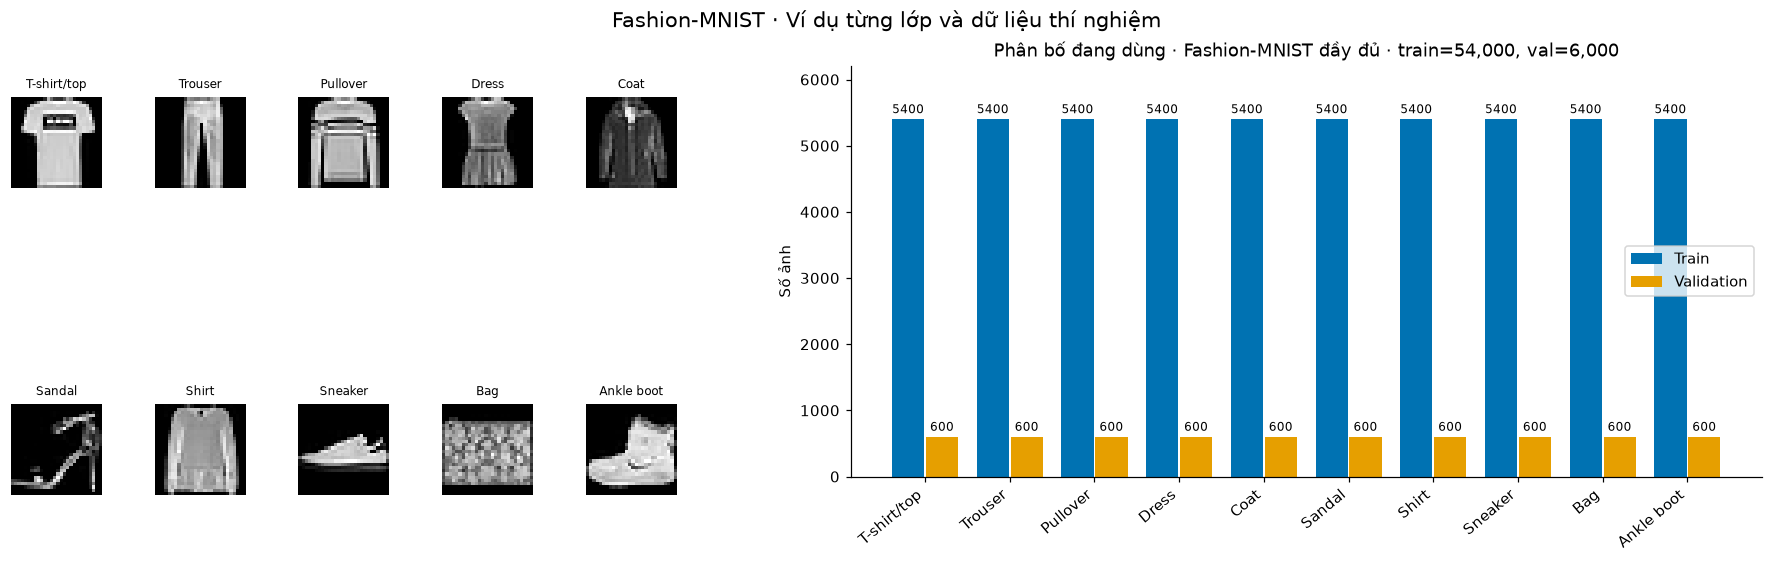

In [5]:
log("EDA", "Gộp ví dụ 10 lớp và phân bố train/validation trong một hình.")
eda_images = np.load(CACHE / "train/images.npy", mmap_mode="r", allow_pickle=False)
eda_labels = np.load(CACHE / "train/labels.npy", allow_pickle=False)
fig = plt.figure(figsize=(16, 5), layout="constrained")
grid = fig.add_gridspec(1, 2, width_ratios=[1, 1.35], wspace=0.22)
gallery = grid[0].subgridspec(2, 5, wspace=0.15, hspace=0.38)
for label in range(10):
    ax = fig.add_subplot(gallery[label // 5, label % 5])
    ax.imshow(eda_images[np.flatnonzero(eda_labels == label)[0]], cmap="gray")
    ax.set_title(CLASS_NAMES[label], fontsize=8)
    ax.axis("off")
ax = fig.add_subplot(grid[1])
positions = np.arange(10)
for offset, dataset, label, color in [
    (-0.2, train_set, "Train", "#0072B2"),
    (0.2, val_set, "Validation", "#E69F00"),
]:
    counts = np.bincount(dataset_labels(dataset), minlength=10)
    bars = ax.bar(positions + offset, counts, width=0.38, label=label, color=color)
    ax.bar_label(bars, fontsize=8, padding=2)
ax.set_xticks(positions, CLASS_NAMES, rotation=40, ha="right")
ax.set_ylabel("Số ảnh")
ax.set_title(
    f"Phân bố đang dùng · {DATA_SCOPE} · train={len(train_set):,}, val={len(val_set):,}"
)
ax.margins(y=0.15)
ax.legend()
fig.suptitle("Fashion-MNIST · Ví dụ từng lớp và dữ liệu thí nghiệm", fontsize=14)
show_figure(fig, "dataset_overview")

## 4. Biểu diễn chuỗi và recurrent cell
Rows/Columns: T=28, feature28; patch 4×4 theo raster: T=49, feature16.
LSTM và GRU được hiện thực từ Linear, sigmoid, tanh; hidden128, một layer,
hidden cuối đi qua head10 logits. LSTM giữ cả hidden/cell; GRU dùng convention
PyTorch với reset nhân sau projection hidden. Không softmax trước cross-entropy.

In [6]:
def image_to_sequence(images, representation):
    if representation == "rows":
        return images[:, 0]
    if representation == "columns":
        return images[:, 0].transpose(1, 2)
    if representation == "patches":
        return F.unfold(images, kernel_size=4, stride=4).transpose(1, 2)
    raise ValueError(f"Unknown representation: {representation}")


class ManualLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.weight_ih = nn.Parameter(torch.empty(4 * hidden_size, input_size))
        self.weight_hh = nn.Parameter(torch.empty(4 * hidden_size, hidden_size))
        self.bias_ih = nn.Parameter(torch.empty(4 * hidden_size))
        self.bias_hh = nn.Parameter(torch.empty(4 * hidden_size))
        for p in self.parameters():
            nn.init.uniform_(p, -(hidden_size**-0.5), hidden_size**-0.5)

    def forward(self, x, state):
        h, c = state
        i, f, g, o = (
            F.linear(x, self.weight_ih, self.bias_ih)
            + F.linear(h, self.weight_hh, self.bias_hh)
        ).chunk(4, 1)
        c = f.sigmoid() * c + i.sigmoid() * g.tanh()
        return o.sigmoid() * c.tanh(), c


class ManualGRUCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.weight_ih = nn.Parameter(torch.empty(3 * hidden_size, input_size))
        self.weight_hh = nn.Parameter(torch.empty(3 * hidden_size, hidden_size))
        self.bias_ih = nn.Parameter(torch.empty(3 * hidden_size))
        self.bias_hh = nn.Parameter(torch.empty(3 * hidden_size))
        for p in self.parameters():
            nn.init.uniform_(p, -(hidden_size**-0.5), hidden_size**-0.5)

    def forward(self, x, h):
        xr, xz, xn = F.linear(x, self.weight_ih, self.bias_ih).chunk(3, 1)
        hr, hz, hn = F.linear(h, self.weight_hh, self.bias_hh).chunk(3, 1)
        reset, update = (xr + hr).sigmoid(), (xz + hz).sigmoid()
        # PyTorch GRU convention: reset multiplies the projected hidden term, including bias.
        candidate = (xn + reset * hn).tanh()
        return (1 - update) * candidate + update * h


class SequenceClassifier(nn.Module):
    def __init__(self, kind, representation, hidden=128):
        super().__init__()
        if kind not in ["lstm", "gru"] or representation not in REPRESENTATION_LABELS:
            raise ValueError("Unknown recurrent family or image representation.")
        self.kind, self.representation, self.hidden = kind, representation, hidden
        features = 16 if representation == "patches" else 28
        self.cell = (ManualLSTMCell if kind == "lstm" else ManualGRUCell)(
            features, hidden
        )
        self.head = nn.Linear(hidden, 10)

    def sequence(self, x):
        return image_to_sequence(x, self.representation)

    def forward(self, x):
        sequence = self.sequence(x)
        h = x.new_zeros(x.shape[0], self.hidden)
        c = torch.zeros_like(h)
        for token in sequence.unbind(1):
            if self.kind == "lstm":
                h, c = self.cell(token, (h, c))
            else:
                h = self.cell(token, h)
        return self.head(h)


log(
    "RECURRENT CELLS",
    "LSTM giữ hidden/cell state, GRU dùng reset/update; vòng lặp theo token tự viết, hidden128 và head10 logits.",
)

[02:58:28] [RECURRENT CELLS] LSTM giữ hidden/cell state, GRU dùng reset/update; vòng lặp theo token tự viết, hidden128 và head10 logits.


## 5. Baseline MLP/CNN-B nội bộ
Huấn luyện hai baseline trên đúng split/seed/normalization của bài này; không dùng code hay artifact từ bài khác.

In [7]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)


class SmallCNN(nn.Module):
    """CNN-B baseline, trained locally on this notebook's split."""

    def __init__(self):
        super().__init__()
        layers = []
        channels = 1
        for width in [32, 64, 128]:
            layers.extend(
                [
                    nn.Conv2d(channels, width, 3, padding=1, bias=False),
                    nn.BatchNorm2d(width),
                    nn.ReLU(),
                    nn.MaxPool2d(2),
                ]
            )
            channels = width
        self.net = nn.Sequential(
            *layers,
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 10),
        )

    def forward(self, images):
        return self.net(images)


SPECS = {
    f"{family}_{representation}": {
        "family": family,
        "representation": representation,
        "sequence_length": 49 if representation == "patches" else 28,
        "features": 16 if representation == "patches" else 28,
    }
    for family in ["lstm", "gru"]
    for representation in REPRESENTATION_LABELS
}
SPECS.update(
    mlp={
        "family": "mlp",
        "representation": "flatten",
        "sequence_length": None,
        "features": 784,
    },
    cnn_b={
        "family": "cnn",
        "representation": "spatial",
        "sequence_length": None,
        "features": None,
    },
)
BASE_RUNS = list(SPECS)


def make_model(run):
    if run == "mlp":
        return MLP()
    if run == "cnn_b":
        return SmallCNN()
    spec = SPECS[run]
    return SequenceClassifier(spec["family"], spec["representation"])


log(
    "BASELINE",
    "MLP 784→256→128→10 và CNN-B định nghĩa inline, huấn luyện tại đây trên cùng split.",
)
lines = [
    "| Model | T × feature | Số tham số | Gradient clipping |",
    "|---|---|---:|---|",
]
for run, spec in SPECS.items():
    model = make_model(run)
    shape = (
        f"{spec['sequence_length']} × {spec['features']}"
        if spec["sequence_length"]
        else spec["representation"]
    )
    clip = "norm 1.0" if spec["family"] in ["lstm", "gru"] else "Không"
    lines.append(
        f"| {MODEL_LABELS[run]} | {shape} | {sum(p.numel() for p in model.parameters()):,} | {clip} |"
    )
    del model
display(Markdown("\n".join(lines)))

[02:58:28] [BASELINE] MLP 784→256→128→10 và CNN-B định nghĩa inline, huấn luyện tại đây trên cùng split.


| Model | T × feature | Số tham số | Gradient clipping |
|---|---|---:|---|
| LSTM · Rows | 28 × 28 | 82,186 | norm 1.0 |
| LSTM · Columns | 28 × 28 | 82,186 | norm 1.0 |
| LSTM · Patch 4×4 | 49 × 16 | 76,042 | norm 1.0 |
| GRU · Rows | 28 × 28 | 61,962 | norm 1.0 |
| GRU · Columns | 28 × 28 | 61,962 | norm 1.0 |
| GRU · Patch 4×4 | 49 × 16 | 57,354 | norm 1.0 |
| MLP | flatten | 235,146 | Không |
| CNN-B | spatial | 94,186 | Không |

## 6. Kiểm chứng recurrent trên GPU
Copy weights sang nn.LSTMCell/nn.GRUCell, đối chiếu 4 timestep và backward qua chuỗi, initial state, input và mọi tham số. Kiểm tra shape/gradient CUDA đủ 8 classifier trước train.

In [8]:
log(
    "KIỂM CHỨNG LSTM/GRU",
    "Đối chiếu nhiều bước thời gian, initial state, input/hidden/cell gradients và toàn bộ parameters trên CUDA float64.",
)
check_records = []


def check_recurrent_cell(custom, reference):
    seed_all(SEED)
    mine = custom(5, 7).to(device=DEVICE, dtype=torch.float64)
    donor = reference(5, 7).to(device=DEVICE, dtype=torch.float64)
    donor.load_state_dict(mine.state_dict(), strict=True)
    x = torch.randn(3, 4, 5, device=DEVICE, dtype=torch.float64, requires_grad=True)
    xr = x.detach().clone().requires_grad_(True)
    h0 = torch.randn(3, 7, device=DEVICE, dtype=torch.float64, requires_grad=True)
    hr0 = h0.detach().clone().requires_grad_(True)
    c0 = torch.randn(3, 7, device=DEVICE, dtype=torch.float64, requires_grad=True)
    cr0 = c0.detach().clone().requires_grad_(True)
    h, hr, c, cr = h0, hr0, c0, cr0
    outputs, expected, cells, reference_cells = [], [], [], []
    for step in range(4):
        if custom is ManualLSTMCell:
            h, c = mine(x[:, step], (h, c))
            hr, cr = donor(xr[:, step], (hr, cr))
            cells.append(c)
            reference_cells.append(cr)
        else:
            h, hr = mine(x[:, step], h), donor(xr[:, step], hr)
        outputs.append(h)
        expected.append(hr)
    output, expected_output = torch.stack(outputs, 1), torch.stack(expected, 1)
    torch.testing.assert_close(output, expected_output, atol=1e-5, rtol=1e-5)
    forward_error = float((output - expected_output).abs().max().detach())
    loss, loss_ref = output.square().sum(), expected_output.square().sum()
    if cells:
        cell_output, cell_reference = (
            torch.stack(cells, 1),
            torch.stack(reference_cells, 1),
        )
        torch.testing.assert_close(cell_output, cell_reference, atol=1e-5, rtol=1e-5)
        loss = loss + cell_output.square().sum()
        loss_ref = loss_ref + cell_reference.square().sum()
    loss.backward()
    loss_ref.backward()
    torch.testing.assert_close(x.grad, xr.grad, atol=1e-5, rtol=1e-5)
    torch.testing.assert_close(h0.grad, hr0.grad, atol=1e-5, rtol=1e-5)
    if cells:
        torch.testing.assert_close(c0.grad, cr0.grad, atol=1e-5, rtol=1e-5)
    for parameter, reference_parameter in zip(mine.parameters(), donor.parameters()):
        torch.testing.assert_close(
            parameter.grad, reference_parameter.grad, atol=1e-5, rtol=1e-5
        )
        assert parameter.grad.is_cuda and torch.isfinite(parameter.grad).all()
    return {
        "cell": custom.__name__,
        "device": str(DEVICE),
        "timesteps": 4,
        "forward_max_error": forward_error,
        "forward_and_gradient_parity": True,
    }


for custom, reference in [(ManualLSTMCell, nn.LSTMCell), (ManualGRUCell, nn.GRUCell)]:
    record = check_recurrent_cell(custom, reference)
    check_records.append(record)
    log(
        "KIỂM CHỨNG",
        f"PASS {record['cell']}: 4 bước / forward + state/input/parameter gradients · max error={record['forward_max_error']:.3e}.",
    )


for run in BASE_RUNS:
    seed_all(SEED)
    model = make_model(run).to(DEVICE)
    images = torch.randn(3, 1, 28, 28, device=DEVICE)
    if SPECS[run]["family"] in ["lstm", "gru"]:
        sequence = model.sequence(images)
        assert tuple(sequence.shape) == (
            3,
            SPECS[run]["sequence_length"],
            SPECS[run]["features"],
        )
    logits = model(images)
    assert tuple(logits.shape) == (3, 10) and logits.is_cuda
    F.cross_entropy(logits, torch.tensor([0, 1, 2], device=DEVICE)).backward()
    assert all(
        p.is_cuda
        and p.grad is not None
        and p.grad.is_cuda
        and torch.isfinite(p.grad).all()
        for p in model.parameters()
    )
    log(
        "KIỂM TRA GPU",
        "PASS output shape, parameters/images/logits/gradient CUDA.",
        MODEL_LABELS[run],
    )
    del model, images, logits
del sequence
torch.cuda.empty_cache()
log("KIỂM CHỨNG", "Hoàn tất kiểm tra GPU; cell này chưa train Fashion-MNIST.")

[02:58:28] [KIỂM CHỨNG LSTM/GRU] Đối chiếu nhiều bước thời gian, initial state, input/hidden/cell gradients và toàn bộ parameters trên CUDA float64.
[02:58:29] [KIỂM CHỨNG] PASS ManualLSTMCell: 4 bước / forward + state/input/parameter gradients · max error=5.551e-17.
[02:58:29] [KIỂM CHỨNG] PASS ManualGRUCell: 4 bước / forward + state/input/parameter gradients · max error=3.331e-16.
[02:58:29] [KIỂM TRA GPU] [LSTM · Rows] PASS output shape, parameters/images/logits/gradient CUDA.
[02:58:29] [KIỂM TRA GPU] [LSTM · Columns] PASS output shape, parameters/images/logits/gradient CUDA.
[02:58:29] [KIỂM TRA GPU] [LSTM · Patch 4×4] PASS output shape, parameters/images/logits/gradient CUDA.
[02:58:29] [KIỂM TRA GPU] [GRU · Rows] PASS output shape, parameters/images/logits/gradient CUDA.
[02:58:29] [KIỂM TRA GPU] [GRU · Columns] PASS output shape, parameters/images/logits/gradient CUDA.
[02:58:29] [KIỂM TRA GPU] [GRU · Patch 4×4] PASS output shape, parameters/images/logits/gradient CUDA.
[02:58:

## 7. Vòng lặp train đầy đủ, GPU và early stopping
Forward → cross-entropy → backward → AdamW step do notebook tự viết.
Batch 128: 422 batch train, 47 batch validation, 79 batch test; không bỏ batch cuối.
Tối đa 100 epoch/model; validation loss phải giảm hơn 0,0001 để reset patience;
dừng sau 4 epoch liên tiếp không đạt ngưỡng. Checkpoint tốt nhất luôn lưu loss thấp nhất,
kể cả cải thiện nhỏ hơn min_delta; không dùng test để chọn model.

Mỗi model giữ một khung text cập nhật tại chỗ: epoch/batch, loss/accuracy,
optimizer updates, AMP skips, GPU/VRAM, tensor/gradient CUDA, validation/test,
checkpoint và early-stop counter. ETA chỉ ước lượng pha hiện tại.
Log chi tiết giữ trong EXECUTION_LOG (RAM).

Riêng LSTM/GRU: unscale gradient AMP rồi clip norm1 trước optimizer step.
MLP/CNN-B không clipping. Notebook giữ hidden/cell state trong vòng lặp theo token;
reference nn.LSTMCell/nn.GRUCell chỉ dùng kiểm chứng phép toán trước train.

Checkpoint giữ weights có validation loss thấp nhất tuyệt đối. Patience chỉ reset khi loss cải thiện hơn `min_delta=0,0001` so với mốc dừng sớm; một cải thiện nhỏ hơn vẫn có thể tạo checkpoint tốt hơn mà không reset patience.

In [9]:
@torch.no_grad()
def evaluate(model, loader, classes, *, run, split, progress=None):
    started = time.perf_counter()
    label = MODEL_LABELS[run]
    if progress is None:
        progress = TextProgress(label)
    progress.start_phase(
        split,
        len(loader),
        len(loader.dataset),
        status="Đánh giá trên CUDA; không cập nhật trọng số",
    )
    model.eval()
    log(
        "ĐÁNH GIÁ",
        f"{split}: {len(loader.dataset):,} ảnh / {len(loader)} batch; eval/no_grad trên {DEVICE}.",
        label,
        console=False,
    )
    cm = torch.zeros(classes, classes, dtype=torch.int64)
    loss_sum, count = 0.0, 0
    failures, failure_classes = [], set()
    for step, (images_cpu, labels_cpu) in enumerate(loader, 1):
        images = images_cpu.to(DEVICE, non_blocking=True)
        labels = labels_cpu.to(DEVICE, non_blocking=True)
        logits = model(images)
        assert images.is_cuda and labels.is_cuda and logits.is_cuda
        loss = F.cross_entropy(logits, labels, reduction="sum")
        if not torch.isfinite(loss):
            raise FloatingPointError(f"{run}/{split}: non-finite evaluation loss")
        loss_sum += loss.item()
        prediction = logits.argmax(1).cpu()
        cm += torch.bincount(
            labels_cpu * classes + prediction, minlength=classes * classes
        ).reshape(classes, classes)
        if len(failure_classes) < classes:
            for j in torch.where(prediction != labels_cpu)[0].tolist():
                truth = int(labels_cpu[j])
                if truth not in failure_classes:
                    failures.append((images_cpu[j].clone(), truth, int(prediction[j])))
                    failure_classes.add(truth)
        count += len(labels)
        progress.update(
            step=step,
            samples=count,
            loss=loss_sum / count,
            accuracy=float(cm.diag().sum()) / count,
            vram=torch.cuda.memory_allocated(DEVICE) / 2**20,
            eval_verified=True,
        )
        if step == 1:
            log(
                "GPU EVAL",
                f"images={images.device}, labels={labels.device}, logits={logits.device}; model={next(model.parameters()).device}.",
                label,
                console=False,
            )
        if step == 1 or step % LOG_BATCH_EVERY == 0 or step == len(loader):
            log(
                "EVAL BATCH",
                f"{split} · {step}/{len(loader)} · {count:,}/{len(loader.dataset):,} ảnh · loss={loss_sum / count:.4f}.",
                label,
                console=False,
            )
    assert count == len(loader.dataset) and count > 0
    tp = cm.diag().double()
    precision = tp / cm.sum(0).clamp_min(1)
    recall = tp / cm.sum(1).clamp_min(1)
    f1 = 2 * precision * recall / (precision + recall).clamp_min(1e-12)
    result = {
        "loss": loss_sum / count,
        "accuracy": float(tp.sum() / count),
        "macro_f1": float(f1.mean()),
        "cm": cm.numpy(),
        "failures": failures,
    }
    log(
        "ĐÁNH GIÁ",
        f"Hoàn tất {split}: {count:,} ảnh · acc={100 * result['accuracy']:.2f}% · F1={result['macro_f1']:.4f} · {time.perf_counter() - started:.2f}s.",
        label,
        console=False,
    )
    evaluation_text = f"{split}: loss={result['loss']:.4f}, acc={100 * result['accuracy']:.2f}%, F1={result['macro_f1']:.4f}"
    metric = "test" if split == "test" else "validation"
    progress.update(
        force=True,
        step=len(loader),
        status=f"Hoàn tất {split}",
        **{metric: evaluation_text},
    )
    return result


def train_classifier(
    model,
    train_set,
    val_set,
    run,
    *,
    max_epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    patience=EARLY_STOP_PATIENCE,
    min_delta=EARLY_STOP_MIN_DELTA,
    progress=None,
    grad_clip=None,
):
    call_started = time.perf_counter()
    if max_epochs < 1 or patience < 1 or min_delta < 0 or batch_size < 1:
        raise ValueError("Invalid training configuration")
    if grad_clip is not None and grad_clip <= 0:
        raise ValueError("Gradient clipping threshold must be positive")
    seed_all(SEED)
    label = MODEL_LABELS[run]
    if progress is None:
        progress = TextProgress(label)
    progress.update(
        force=True, max_epochs=max_epochs, patience=patience, min_delta=min_delta
    )
    model.to(DEVICE)
    assert all(p.is_cuda for p in model.parameters())
    assert all(b.is_cuda for b in model.buffers())

    protocol = {
        "run_id": RUN_ID,
        "run": run,
        "dataset_scope": "full",
        "seed": SEED,
        "train_samples": len(train_set),
        "val_samples": len(val_set),
        "test_samples": len(test_set),
        "max_epochs": max_epochs,
        "patience": patience,
        "min_delta": min_delta,
        "checkpoint_metric": "minimum_validation_loss",
        "lr": lr,
        "weight_decay": weight_decay,
        "batch_size": batch_size,
        "split": SPLIT_HASH,
        "versions": VERSIONS,
        "device": str(DEVICE),
        "gpu": torch.cuda.get_device_name(DEVICE),
        "architecture": str(model),
        "fresh_initialization": True,
        "grad_clip": grad_clip,
    }
    config_hash = digest(protocol)
    RUN_CONFIGS[run] = protocol
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler = torch.amp.GradScaler("cuda", init_scale=1024)
    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=False,
    )
    val_loader = DataLoader(
        val_set,
        batch_size=batch_size,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=False,
    )
    history = []
    best_loss, early_best_loss, bad = math.inf, math.inf, 0
    session_updates = 0
    stopping_reason = "maximum_epochs"
    torch.cuda.reset_peak_memory_stats(DEVICE)
    log(
        "TRAIN",
        f"Khởi tạo từ đầu · {len(train_set):,} train / {len(val_set):,} val · {len(train_loader)} batch/epoch · AdamW lr={lr:g}, weight_decay={weight_decay:g} · tối đa {max_epochs} epoch.",
        label,
        console=False,
    )
    for epoch in range(1, max_epochs + 1):
        torch.cuda.synchronize(DEVICE)
        started = time.perf_counter()
        log(
            "TRAIN",
            f"Epoch {epoch}/{max_epochs} · GPU={torch.cuda.get_device_name(DEVICE)} · {len(train_loader)} batch cập nhật trọng số.",
            label,
            console=False,
        )
        progress.start_phase(
            "TRAIN",
            len(train_loader),
            len(train_set),
            epoch=epoch,
            updates=0,
            skips=0,
            status="Forward → backward → AdamW trên CUDA"
            + (f" · clip norm {grad_clip:g}" if grad_clip is not None else ""),
        )
        model.train()
        total_loss, total, correct, optimizer_updates, skipped_updates = 0.0, 0, 0, 0, 0
        for step, (images, labels) in enumerate(train_loader, 1):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda"):
                logits = model(images)
                loss = F.cross_entropy(logits, labels)
            if not torch.isfinite(loss):
                raise FloatingPointError(f"{run}: non-finite training loss")
            scaler.scale(loss).backward()
            if step == 1:
                gradients = [p.grad for p in model.parameters() if p.requires_grad]
                assert images.is_cuda and labels.is_cuda and logits.is_cuda
                assert all(g is not None and g.is_cuda for g in gradients)
                progress.update(train_verified=True)
                log(
                    "GPU TRAIN",
                    f"parameters={next(model.parameters()).device}; images={images.device}; labels={labels.device}; logits={logits.device}; gradient={gradients[0].device}; AMP=True.",
                    label,
                    console=False,
                )
            if grad_clip is not None:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            old_scale = scaler.get_scale()
            scaler.step(optimizer)
            scaler.update()
            updated = scaler.get_scale() >= old_scale
            optimizer_updates += int(updated)
            skipped_updates += int(not updated)
            if not updated:
                log(
                    "AMP",
                    f"Epoch {epoch} batch {step}: overflow, bỏ optimizer update; scale {old_scale:g} → {scaler.get_scale():g}.",
                    label,
                    console=False,
                )
            total_loss += loss.item() * len(labels)
            total += len(labels)
            correct += (logits.argmax(1) == labels).sum().item()
            progress.update(
                step=step,
                samples=total,
                loss=total_loss / total,
                accuracy=correct / total,
                updates=optimizer_updates,
                skips=skipped_updates,
                vram=torch.cuda.memory_allocated(DEVICE) / 2**20,
                force=step == len(train_loader),
            )
            if step == 1 or step % LOG_BATCH_EVERY == 0 or step == len(train_loader):
                log(
                    "TRAIN BATCH",
                    f"Epoch {epoch}/{max_epochs} · batch {step}/{len(train_loader)} · {total:,}/{len(train_set):,} ảnh · loss={total_loss / total:.4f}, acc={100 * correct / total:.2f}% · updates={optimizer_updates}, AMP skips={skipped_updates} · CUDA VRAM={torch.cuda.memory_allocated(DEVICE) / 2**20:.0f} MiB · {time.perf_counter() - started:.1f}s.",
                    label,
                    console=False,
                )
        assert total == len(train_set) and optimizer_updates > 0
        session_updates += optimizer_updates
        validation = evaluate(
            model,
            val_loader,
            len(CLASS_NAMES),
            run=run,
            split=f"validation epoch {epoch}",
            progress=progress,
        )
        improved = validation["loss"] < best_loss
        if improved:
            best_loss = validation["loss"]
            remember_checkpoint(
                run,
                {
                    "model": model.state_dict(),
                    "epoch": epoch,
                    "val_loss": best_loss,
                    "config_hash": config_hash,
                },
            )
        significant = validation["loss"] < early_best_loss - min_delta
        if significant:
            early_best_loss = validation["loss"]
            bad = 0
        else:
            bad += 1
        torch.cuda.synchronize(DEVICE)
        row = {
            "epoch": epoch,
            "train_loss": total_loss / total,
            "train_accuracy": correct / total,
            "val_loss": validation["loss"],
            "val_accuracy": validation["accuracy"],
            "val_macro_f1": validation["macro_f1"],
            "seconds": time.perf_counter() - started,
            "optimizer_updates": optimizer_updates,
            "amp_skips": skipped_updates,
            "train_samples": total,
            "train_batches": len(train_loader),
            "early_stop_bad_epochs": bad,
        }
        history.append(row)
        completed = bad >= patience or epoch == max_epochs
        if bad >= patience:
            stopping_reason = "early_stopping"

        if improved:
            checkpoint_text = (
                f"Best checkpoint · epoch {epoch} · val loss={best_loss:.5f}"
            )
        else:
            checkpoint_text = progress.state["checkpoint"]
        progress.update(
            force=True,
            bad=bad,
            checkpoint=checkpoint_text,
            status=f"Epoch {epoch} xong: train loss={row['train_loss']:.4f}, acc={100 * row['train_accuracy']:.2f}%; "
            + (
                "early stopping"
                if bad >= patience
                else "đạt giới hạn epoch"
                if completed
                else "tiếp tục epoch sau"
            ),
        )
        log(
            "EPOCH",
            f"{epoch}/{max_epochs} · train loss={row['train_loss']:.4f}, acc={100 * row['train_accuracy']:.2f}% · val loss={row['val_loss']:.4f}, acc={100 * row['val_accuracy']:.2f}%, F1={row['val_macro_f1']:.4f} · {row['seconds']:.2f}s · {'lưu Best checkpoint' if improved else 'giữ Best checkpoint'} · early-stop counter={bad}/{patience}, min_delta={min_delta:g}.",
            label,
            console=False,
        )
        if completed:
            log(
                "KẾT THÚC TRAIN",
                f"Early stopping: {bad} epoch không cải thiện đủ min_delta."
                if bad >= patience
                else f"Đạt giới hạn {max_epochs} epoch.",
                label,
                console=False,
            )
            break
    state = load_checkpoint(run)
    assert state["config_hash"] == config_hash
    model.load_state_dict(state["model"])
    log(
        "CHECKPOINT",
        f"Nạp Best checkpoint của run {RUN_ID}: epoch {state['epoch']}, validation loss={state['val_loss']:.5f}; trọng số trên {next(model.parameters()).device}.",
        label,
        console=False,
    )
    validation = evaluate(
        model,
        val_loader,
        len(CLASS_NAMES),
        run=run,
        split="validation best checkpoint",
        progress=progress,
    )
    result = {
        "model": label,
        "run_status": "trained",
        "run_id": RUN_ID,
        "dataset_scope": "full",
        "run": run,
        "seed": SEED,
        "epochs_this_session": len(history),
        "epochs_recorded": len(history),
        "optimizer_updates_this_session": session_updates,
        "training_seconds_this_session": sum(r["seconds"] for r in history),
        "session_seconds": time.perf_counter() - call_started,
        "val_accuracy": validation["accuracy"],
        "val_macro_f1": validation["macro_f1"],
        "val_loss": validation["loss"],
        "parameters": sum(p.numel() for p in model.parameters()),
        "trainable": sum(p.numel() for p in model.parameters() if p.requires_grad),
        "seconds": sum(r["seconds"] for r in history),
        "peak_vram_mb": torch.cuda.max_memory_allocated(DEVICE) / 2**20,
        "session_peak_vram_mb": torch.cuda.max_memory_allocated(DEVICE) / 2**20,
        "best_epoch": state["epoch"],
        "stopping_reason": stopping_reason,
        "seconds_per_epoch": sum(r["seconds"] for r in history) / len(history),
        "grad_clip": grad_clip,
    }

    log(
        "TÓM TẮT MODEL",
        f"Huấn luyện: {len(history)} epoch / {session_updates} optimizer updates · best epoch={state['epoch']} · val accuracy={100 * result['val_accuracy']:.2f}% · GPU peak VRAM={result['peak_vram_mb']:.0f} MiB · kết thúc={stopping_reason}.",
        label,
        console=False,
    )
    progress.update(
        force=True,
        status=f"Train hoàn tất: {len(history)} epoch, {session_updates} updates; {stopping_reason}. Đã nạp best epoch {state['epoch']}; chuẩn bị test.",
    )
    return result, history, validation


log(
    "TRAINING ENGINE",
    "Đã định nghĩa train/evaluate trên CUDA và early stopping; cell này chưa train.",
)

[02:58:29] [TRAINING ENGINE] Đã định nghĩa train/evaluate trên CUDA và early stopping; cell này chưa train.


In [10]:
def display_result_table(results, histories):
    training = [
        "| Model | Epoch | Best epoch | Optimizer updates | AMP skips | Dừng huấn luyện | GPU peak (MiB) |",
        "|---|---:|---:|---:|---:|---|---:|",
    ]
    metrics = [
        "| Model | Train acc tại best (%) | Val acc (%) | Val macro-F1 | Test acc (%) | Test macro-F1 | Test loss | Tham số | Train + val (s) | s/epoch |",
        "|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|",
    ]
    for result in results:
        history = histories[result["run"]]
        best = next(row for row in history if row["epoch"] == result["best_epoch"])
        stopping = (
            "Early stopping"
            if result["stopping_reason"] == "early_stopping"
            else "Giới hạn epoch"
        )
        training.append(
            f"| {result['model']} | {len(history)} | {result['best_epoch']} | "
            f"{result['optimizer_updates_this_session']:,} | {sum(row['amp_skips'] for row in history):,} | "
            f"{stopping} | {result['peak_vram_mb']:.0f} |"
        )
        metrics.append(
            f"| {result['model']} | {100 * best['train_accuracy']:.2f} | "
            f"{100 * result['val_accuracy']:.2f} | {result['val_macro_f1']:.4f} | "
            f"{100 * result['test_accuracy']:.2f} | {result['test_macro_f1']:.4f} | "
            f"{result['test_loss']:.4f} | {result['parameters']:,} | "
            f"{result['seconds']:.2f} | {result['seconds'] / len(history):.3f} |"
        )
    display(Markdown("**Huấn luyện trên CUDA**\n\n" + "\n".join(training)))
    display(
        Markdown(
            "**Kết quả tại checkpoint chọn bằng validation loss**\n\n"
            + "\n".join(metrics)
        )
    )
    display(
        Markdown(
            "Train accuracy được đo trong train mode khi cập nhật trọng số; "
            "validation/test được đo trong eval mode. Thời gian gồm training và validation, "
            "không gồm vẽ hình hay test."
        )
    )


def comparison_plot(results):
    log("BIỂU ĐỒ", "So sánh validation, capacity và thời gian train của tám model.")
    names = [MODEL_TICKS[r["run"]] for r in results]
    colors = [MODEL_COLORS[r["run"]] for r in results]
    positions = np.arange(len(results))
    fig, axes = plt.subplots(1, 3, figsize=(19, 8.6), sharey=True)
    for offset, key, label, hatch in [
        (-0.18, "val_accuracy", "Accuracy", ""),
        (0.18, "val_macro_f1", "Macro-F1", "//"),
    ]:
        bars = axes[0].barh(
            positions + offset,
            [100 * r[key] for r in results],
            height=0.32,
            color=colors,
            hatch=hatch,
            label=label,
        )
        axes[0].bar_label(bars, fmt="%.1f", fontsize=8, padding=3)
    axes[0].set_xlim(0, 110)
    axes[0].set_xlabel("Validation (%)")
    axes[0].set_title("Chất lượng validation")
    axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=9)
    for ax, key, title, xlabel, fmt in [
        (axes[1], "parameters", "Capacity", "Số tham số", "{:,.0f}"),
        (axes[2], "seconds", "Chi phí train + validation", "Giây", "{:.2f}"),
    ]:
        values = [r[key] for r in results]
        bars = ax.barh(positions, values, height=0.62, color=colors)
        ax.bar_label(
            bars, labels=[fmt.format(v) for v in values], padding=3, fontsize=9
        )
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.margins(x=0.22)
    for ax in axes:
        ax.set_yticks(positions, names, fontsize=9)
        ax.grid(axis="x", alpha=0.15)
        ax.set_axisbelow(True)
    axes[0].invert_yaxis()
    fig.suptitle(
        f"{NAME} · Tám model · {DATA_SCOPE} · validation n={len(val_set):,}",
        fontsize=14,
    )
    show_figure(fig, "comparison")


def confusion_plots(results, evaluations, split):
    split_label = "Test" if split == "test" else "Validation"
    log(
        "CONFUSION MATRIX",
        f"{split_label}: bốn cặp đặt ngang; mỗi ô = số ảnh và % theo hàng.",
    )
    for pair_index, pair in enumerate(
        [results[index : index + 2] for index in range(0, len(results), 2)], start=1
    ):
        fig, axes = plt.subplots(1, 2, figsize=(16, 7.4))
        for ax, result in zip(axes, pair):
            cm = evaluations[result["run"]][split]["cm"]
            normalized = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
            image = ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1)
            for truth in range(10):
                for prediction in range(10):
                    count = int(cm[truth, prediction])
                    percentage = normalized[truth, prediction] * 100
                    text = f"{count}\n{percentage:.1f}%" if count else "0"
                    ax.text(
                        prediction,
                        truth,
                        text,
                        ha="center",
                        va="center",
                        fontsize=8,
                        color="white"
                        if normalized[truth, prediction] >= 0.55
                        else "#172B4D",
                    )
            ax.set_xticks(range(10), CLASS_NAMES, rotation=45, ha="right", fontsize=9)
            ax.set_yticks(range(10), CLASS_NAMES, fontsize=9)
            ax.set_xticks(np.arange(-0.5, 10, 1), minor=True)
            ax.set_yticks(np.arange(-0.5, 10, 1), minor=True)
            ax.grid(which="minor", color="white", linewidth=0.6)
            ax.tick_params(which="minor", bottom=False, left=False)
            ax.set_xlabel("Nhãn dự đoán")
            ax.set_ylabel("Nhãn thật")
            accuracy = np.trace(cm) / cm.sum()
            ax.set_title(
                f"{result['model']} · {split_label} n={int(cm.sum()):,}\nAccuracy={100 * accuracy:.2f}%",
                fontsize=12,
            )
            bar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.02)
            bar.set_ticks(
                [0, 0.25, 0.5, 0.75, 1], labels=["0%", "25%", "50%", "75%", "100%"]
            )
            bar.set_label("Tỷ lệ theo lớp thật", fontsize=9)
        fig.suptitle(
            f"{NAME} · {split_label} · {DATA_SCOPE} · Mỗi ô: số ảnh / % trên tổng lớp thật",
            fontsize=14,
        )
        show_figure(fig, f"confusion_{split}_pair_{pair_index}")


def failure_examples_plot(results, evaluations, split):
    matrices = [evaluations[result["run"]][split]["cm"] for result in results]
    recalls = np.stack([np.diag(cm) / np.maximum(cm.sum(axis=1), 1) for cm in matrices])
    difficult_classes = np.argsort(recalls.mean(axis=0), kind="stable")[:4]
    log(
        "PHÂN TÍCH LỖI",
        "Gộp 4 lớp có recall trung bình thấp nhất; mỗi hàng một model, mỗi cột cùng lớp thật.",
    )
    fig, axes = plt.subplots(len(results), 4, figsize=(12, 2.6 * len(results)))
    for row_index, result in enumerate(results):
        failures = evaluations[result["run"]][split]["failures"]
        for column, ax in enumerate(axes[row_index]):
            truth = int(difficult_classes[column])
            example = next((item for item in failures if item[1] == truth), None)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            if column == 0:
                ax.set_ylabel(
                    result["model"],
                    fontsize=9,
                    color=MODEL_COLORS[result["run"]],
                    labelpad=12,
                )
            if example is not None:
                pixels, truth, prediction = example
                ax.imshow(
                    np.clip(pixels.squeeze().numpy() * std + mean, 0, 1),
                    cmap="gray",
                    vmin=0,
                    vmax=1,
                )
                ax.set_title(
                    f"Thật: {CLASS_NAMES[truth]}\nDự đoán: {CLASS_NAMES[prediction]}",
                    fontsize=10,
                )
            else:
                ax.set_title(f"Thật: {CLASS_NAMES[truth]}", fontsize=10)
                ax.text(
                    0.5,
                    0.5,
                    "Không có ảnh sai lớp này",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
    fig.suptitle(
        f"{NAME} · Ảnh lỗi {'test' if split == 'test' else 'validation'} · 4 lớp có recall trung bình thấp nhất\n"
        "Một lỗi đầu tiên mỗi lớp/model; không đại diện toàn bộ lỗi",
        fontsize=13,
    )
    show_figure(fig, f"failure_examples_{split}")


def plot_curve_groups(histories, groups):
    """One horizontal row of comparable groups per metric."""
    log(
        "LEARNING CURVES",
        "Gộp theo tokenizer/representation; màu theo model, nét đứt train, nét liền validation.",
    )
    for metric, scale, ylabel in [
        ("loss", 1, "Cross-entropy loss"),
        ("accuracy", 100, "Accuracy (%)"),
    ]:
        fig, axes = plt.subplots(1, len(groups), figsize=(18, 5.1), squeeze=False)
        for ax, (title, runs) in zip(axes[0], groups):
            for run in runs:
                rows = histories[run]
                for split, style in [("train", "--"), ("val", "-")]:
                    ax.plot(
                        [r["epoch"] for r in rows],
                        [scale * r[f"{split}_{metric}"] for r in rows],
                        style,
                        color=MODEL_COLORS[run],
                        linewidth=1.6,
                        label=f"{MODEL_CURVE_LABELS[run]} · {split}",
                    )
            ax.set_title(title)
            ax.set_xlabel("Epoch của lần train hiện tại")
            ax.set_ylabel(ylabel)
            ax.xaxis.set_major_locator(MaxNLocator(nbins=7, integer=True))
            ax.grid(alpha=0.2)
            ax.legend(fontsize=8, ncol=2)
            if metric == "accuracy":
                ax.set_ylim(0, 100)
        fig.suptitle(f"{NAME} · {ylabel} · Cùng split và protocol", fontsize=14)
        show_figure(fig, f"learning_curves_{metric}")


def plot_focus_curves(selected, histories, stem, title):
    log("LEARNING CURVES", title)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5.4))
    for result in selected:
        run = result["run"]
        rows = histories[run]
        for ax, metric, scale in [(axes[0], "loss", 1), (axes[1], "accuracy", 100)]:
            for split, style in [("train", "--"), ("val", "-")]:
                ax.plot(
                    [r["epoch"] for r in rows],
                    [scale * r[f"{split}_{metric}"] for r in rows],
                    style,
                    linewidth=1.6,
                    color=MODEL_COLORS[run],
                    label=f"{result['model']} · {split}",
                )
    axes[0].set_ylabel("Cross-entropy loss")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_ylim(0, 100)
    for ax in axes:
        ax.set_xlabel("Epoch của lần train hiện tại")
        ax.xaxis.set_major_locator(MaxNLocator(nbins=9, integer=True))
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8, ncol=2)
    fig.suptitle(f"{NAME} · {title}", fontsize=14)
    show_figure(fig, stem)


def paired_comparison(results, pairs, families, stem, title):
    log("SO SÁNH CẶP", title)
    by_run = {r["run"]: r for r in results}
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    positions = np.arange(len(pairs))
    for ax, metric, ylabel in zip(
        axes,
        ["val_accuracy", "parameters", "seconds_per_epoch"],
        ["Validation accuracy (%)", "Số tham số", "Train + val / epoch (s)"],
    ):
        for side, family in enumerate(families):
            values = [by_run[pair[side + 1]][metric] for pair in pairs]
            if metric == "val_accuracy":
                values = [100 * value for value in values]
            bars = ax.bar(
                positions + (side - 0.5) * 0.35,
                values,
                width=0.34,
                label=family,
                color=["#0072B2", "#E69F00"][side],
            )
            ax.bar_label(
                bars,
                labels=[
                    f"{v:,.0f}" if metric == "parameters" else f"{v:.2f}"
                    for v in values
                ],
                fontsize=8,
                padding=2,
            )
        ax.set_xticks(positions, [pair[0] for pair in pairs])
        ax.set_ylabel(ylabel)
        ax.margins(y=0.2)
        ax.legend()
        ax.grid(axis="y", alpha=0.15)
        ax.set_axisbelow(True)
    fig.suptitle(f"{NAME} · {title}", fontsize=14)
    show_figure(fig, stem)


def load_best_model(run):
    model = make_model(run).to(DEVICE)

    state = load_checkpoint(run)
    protocol = RUN_CONFIGS[run]
    assert state["config_hash"] == digest(protocol)
    model.load_state_dict(state["model"], strict=True)
    model.eval()
    return model


def train_one(run, *, grad_clip=None):
    seed_all(SEED)
    model = make_model(run)
    progress = TextProgress(MODEL_LABELS[run])
    result, history, validation = train_classifier(
        model,
        train_set,
        val_set,
        run,
        progress=progress,
        grad_clip=grad_clip,
    )
    result.update(SPECS[run])
    histories[run] = history
    evaluations[run] = {"val": validation}
    progresses[run] = progress
    results.append(result)
    del model
    torch.cuda.empty_cache()


def test_all():
    log(
        "TEST",
        "Đã train đủ 8 model và khóa mọi lựa chọn bằng validation; test đủ 10.000 ảnh/model.",
    )
    for result in results:
        run = result["run"]
        model = load_best_model(run)
        progress = progresses[run]
        test = evaluate(
            model,
            DataLoader(
                test_set,
                batch_size=BATCH_SIZE,
                num_workers=NUM_WORKERS,
                pin_memory=True,
                drop_last=False,
            ),
            len(CLASS_NAMES),
            run=run,
            split="test",
            progress=progress,
        )
        evaluations[run]["test"] = test
        result.update(
            test_accuracy=test["accuracy"],
            test_macro_f1=test["macro_f1"],
            test_loss=test["loss"],
        )

        progress.update(
            force=True,
            status=f"HOÀN TẤT MODEL · {result['epochs_this_session']} epoch / {result['optimizer_updates_this_session']} updates · best epoch {result['best_epoch']} · {result['stopping_reason']} · đủ 10.000 ảnh test.",
        )
        del model
        torch.cuda.empty_cache()


def report_error_pairs(results):
    lines = [
        "| Model | Nhầm nhiều nhất: thật → dự đoán | Số ảnh | % lớp thật |",
        "|---|---|---:|---:|",
    ]
    for result in results:
        cm = evaluations[result["run"]]["test"]["cm"]
        off = cm.copy()
        np.fill_diagonal(off, 0)
        truth, prediction = np.unravel_index(off.argmax(), off.shape)
        count = int(off[truth, prediction])
        pair = (
            f"{CLASS_NAMES[truth]} → {CLASS_NAMES[prediction]}"
            if count
            else "Không có ảnh sai"
        )
        percentage = 100 * count / max(1, int(cm[truth].sum()))
        lines.append(f"| {result['model']} | {pair} | {count} | {percentage:.1f}% |")
    display(Markdown("\n".join(lines)))


log(
    "TRÌNH BÀY",
    "Đã định nghĩa bảng, đồ thị gộp, so sánh cặp, checkpoint và đánh giá test.",
)

[02:58:29] [TRÌNH BÀY] Đã định nghĩa bảng, đồ thị gộp, so sánh cặp, checkpoint và đánh giá test.


## 8. Huấn luyện 6 recurrent run + 2 baseline, rồi test
Toàn bộ lịch thí nghiệm chốt trước test. Chọn LSTM/GRU đại diện bằng validation accuracy/F1/loss; vẫn đánh giá test và lưu confusion matrix đủ cả 8 model.

In [11]:
log(
    "THÍ NGHIỆM",
    "Huấn luyện 6 run LSTM/GRU × Rows/Columns/Patch và 2 baseline MLP/CNN-B.",
)
results, histories, evaluations, progresses = [], {}, {}, {}
for run in BASE_RUNS:
    clipping = 1.0 if SPECS[run]["family"] in ["lstm", "gru"] else None
    train_one(run, grad_clip=clipping)
assert len(results) == 8
# Select the representatives for focused plots using validation, before any test.
best_lstm = max(
    [r for r in results if r["family"] == "lstm"],
    key=lambda r: (r["val_accuracy"], r["val_macro_f1"], -r["val_loss"]),
)
best_gru = max(
    [r for r in results if r["family"] == "gru"],
    key=lambda r: (r["val_accuracy"], r["val_macro_f1"], -r["val_loss"]),
)
selected_runs = [best_lstm["run"], best_gru["run"], "mlp", "cnn_b"]

test_all()
log(
    "THÍ NGHIỆM",
    f"Hoàn tất 8 model: {sum(r['epochs_this_session'] for r in results)} epoch / {sum(r['optimizer_updates_this_session'] for r in results)} optimizer updates.",
)

[02:58:29] [THÍ NGHIỆM] Huấn luyện 6 run LSTM/GRU × Rows/Columns/Patch và 2 baseline MLP/CNN-B.
[03:54:39] [TEST] Đã train đủ 8 model và khóa mọi lựa chọn bằng validation; test đủ 10.000 ảnh/model.
[03:54:45] [THÍ NGHIỆM] Hoàn tất 8 model: 238 epoch / 100434 optimizer updates.


LSTM · Rows | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Epoch 24/100 (giới hạn; có early stopping)
test [########################] 100.0% | batch 79/79 | ảnh 10,000/10,000
Loss=0.2940 | Accuracy=89.70% | Updates train/epoch=422 | AMP skips train/epoch=0 | VRAM=18 MiB
Validation: validation best checkpoint: loss=0.2746, acc=89.95%, F1=0.8990
Test: test: loss=0.2940, acc=89.70%, F1=0.8965
Checkpoint: Best checkpoint · epoch 14 · val loss=0.27463 | Early stop=10/10 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:56:10 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 24 epoch / 10128 updates · best epoch 14 · early_stopping · đủ 10.000 ảnh test.

LSTM · Columns | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Epoch 29/100 (giới hạn; có early stopping)
test [########################] 100.0% | batch 79/79 | ảnh 10,000/10,000
Loss=0.3260 | Accuracy=88.81% | Updates train/epoch=422 | AMP skips train/epoch=0 | VRAM=18 MiB
Validation: validation best checkpoint: loss=0.3079, acc=88.72%, F1=0.8881
Test: test: loss=0.3260, acc=88.81%, F1=0.8885
Checkpoint: Best checkpoint · epoch 19 · val loss=0.30789 | Early stop=10/10 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:49:19 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 29 epoch / 12238 updates · best epoch 19 · early_stopping · đủ 10.000 ảnh test.

LSTM · Patch 4×4 | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Epoch 34/100 (giới hạn; có early stopping)
test [########################] 100.0% | batch 79/79 | ảnh 10,000/10,000
Loss=0.3414 | Accuracy=88.22% | Updates train/epoch=422 | AMP skips train/epoch=0 | VRAM=18 MiB
Validation: validation best checkpoint: loss=0.3111, acc=88.62%, F1=0.8861
Test: test: loss=0.3414, acc=88.22%, F1=0.8823
Checkpoint: Best checkpoint · epoch 24 · val loss=0.31109 | Early stop=10/10 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:41:47 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 34 epoch / 14348 updates · best epoch 24 · early_stopping · đủ 10.000 ảnh test.

GRU · Rows | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Epoch 26/100 (giới hạn; có early stopping)
test [########################] 100.0% | batch 79/79 | ảnh 10,000/10,000
Loss=0.2882 | Accuracy=90.06% | Updates train/epoch=422 | AMP skips train/epoch=0 | VRAM=18 MiB
Validation: validation best checkpoint: loss=0.2589, acc=90.47%, F1=0.9044
Test: test: loss=0.2882, acc=90.06%, F1=0.9001
Checkpoint: Best checkpoint · epoch 20 · val loss=0.25889 | Early stop=10/10 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:27:33 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 26 epoch / 10972 updates · best epoch 20 · early_stopping · đủ 10.000 ảnh test.

GRU · Columns | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Epoch 29/100 (giới hạn; có early stopping)
test [########################] 100.0% | batch 79/79 | ảnh 10,000/10,000
Loss=0.3137 | Accuracy=89.51% | Updates train/epoch=422 | AMP skips train/epoch=0 | VRAM=18 MiB
Validation: validation best checkpoint: loss=0.2868, acc=89.83%, F1=0.8983
Test: test: loss=0.3137, acc=89.51%, F1=0.8951
Checkpoint: Best checkpoint · epoch 19 · val loss=0.28679 | Early stop=10/10 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:21:00 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 29 epoch / 12238 updates · best epoch 19 · early_stopping · đủ 10.000 ảnh test.

GRU · Patch 4×4 | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Epoch 30/100 (giới hạn; có early stopping)
test [########################] 100.0% | batch 79/79 | ảnh 10,000/10,000
Loss=0.3352 | Accuracy=88.44% | Updates train/epoch=422 | AMP skips train/epoch=0 | VRAM=18 MiB
Validation: validation best checkpoint: loss=0.3025, acc=89.05%, F1=0.8900
Test: test: loss=0.3352, acc=88.44%, F1=0.8841
Checkpoint: Best checkpoint · epoch 20 · val loss=0.30246 | Early stop=10/10 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:14:13 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 30 epoch / 12660 updates · best epoch 20 · early_stopping · đủ 10.000 ảnh test.

MLP | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Epoch 26/100 (giới hạn; có early stopping)
test [########################] 100.0% | batch 79/79 | ảnh 10,000/10,000
Loss=0.3142 | Accuracy=89.45% | Updates train/epoch=422 | AMP skips train/epoch=0 | VRAM=18 MiB
Validation: validation best checkpoint: loss=0.2841, acc=89.47%, F1=0.8951
Test: test: loss=0.3142, acc=89.45%, F1=0.8948
Checkpoint: Best checkpoint · epoch 16 · val loss=0.28405 | Early stop=10/10 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:02:36 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 26 epoch / 10972 updates · best epoch 16 · early_stopping · đủ 10.000 ảnh test.

CNN-B | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Epoch 40/100 (giới hạn; có early stopping)
test [########################] 100.0% | batch 79/79 | ảnh 10,000/10,000
Loss=0.2320 | Accuracy=91.97% | Updates train/epoch=422 | AMP skips train/epoch=0 | VRAM=18 MiB
Validation: validation best checkpoint: loss=0.2186, acc=91.92%, F1=0.9190
Test: test: loss=0.2320, acc=91.97%, F1=0.9193
Checkpoint: Best checkpoint · epoch 30 · val loss=0.21862 | Early stop=10/10 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:01:46 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 40 epoch / 16878 updates · best epoch 30 · early_stopping · đủ 10.000 ảnh test.

## 9. Kết quả, learning curves và so sánh baseline
Rows/Columns/Patch đặt thành ba panel, mỗi panel so LSTM/GRU. Loss và accuracy tách theo hàng hình có legend. Baseline curves gộp LSTM/GRU đại diện với MLP/CNN-B; bảng hiển thị thời gian/epoch và capacity.

Thời gian trong khung tiến trình tính từ khi bắt đầu run, gồm thời gian chờ các model khác nếu test được thực hiện sau toàn bộ huấn luyện. Bảng train + validation cộng thời gian các pha chạy thực tế, không tính thời gian chờ.

[03:54:45] [BẢNG KẾT QUẢ] So sánh LSTM/GRU từng representation và baseline MLP/CNN-B train nội bộ.
[03:54:45] [BIỂU ĐỒ] So sánh validation, capacity và thời gian train của tám model.
[HÌNH] comparison · hiển thị trong output cell
[03:54:46] [SO SÁNH CẶP] LSTM vs GRU · cùng representation, hidden128
[HÌNH] recurrent_representation_comparison · hiển thị trong output cell
[03:54:46] [LEARNING CURVES] Gộp theo tokenizer/representation; màu theo model, nét đứt train, nét liền validation.
[HÌNH] learning_curves_loss · hiển thị trong output cell
[HÌNH] learning_curves_accuracy · hiển thị trong output cell
[03:54:47] [LEARNING CURVES] LSTM/GRU chọn bằng validation và MLP/CNN-B huấn luyện
[HÌNH] baseline_curves · hiển thị trong output cell


**Huấn luyện trên CUDA**

| Model | Epoch | Best epoch | Optimizer updates | AMP skips | Dừng huấn luyện | GPU peak (MiB) |
|---|---:|---:|---:|---:|---|---:|
| LSTM · Rows | 24 | 14 | 10,128 | 0 | Early stopping | 27 |
| LSTM · Columns | 29 | 19 | 12,238 | 0 | Early stopping | 27 |
| LSTM · Patch 4×4 | 34 | 24 | 14,348 | 0 | Early stopping | 34 |
| GRU · Rows | 26 | 20 | 10,972 | 0 | Early stopping | 28 |
| GRU · Columns | 29 | 19 | 12,238 | 0 | Early stopping | 28 |
| GRU · Patch 4×4 | 30 | 20 | 12,660 | 0 | Early stopping | 35 |
| MLP | 26 | 16 | 10,972 | 0 | Early stopping | 23 |
| CNN-B | 40 | 30 | 16,878 | 2 | Early stopping | 57 |

**Kết quả tại checkpoint chọn bằng validation loss**

| Model | Train acc tại best (%) | Val acc (%) | Val macro-F1 | Test acc (%) | Test macro-F1 | Test loss | Tham số | Train + val (s) | s/epoch |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| LSTM · Rows | 91.95 | 89.95 | 0.8990 | 89.70 | 0.8965 | 0.2940 | 82,186 | 410.70 | 17.113 |
| LSTM · Columns | 92.79 | 88.72 | 0.8881 | 88.81 | 0.8885 | 0.3260 | 82,186 | 452.70 | 15.610 |
| LSTM · Patch 4×4 | 92.40 | 88.62 | 0.8861 | 88.22 | 0.8823 | 0.3414 | 76,042 | 853.58 | 25.105 |
| GRU · Rows | 93.95 | 90.47 | 0.9044 | 90.06 | 0.9001 | 0.2882 | 61,962 | 393.42 | 15.132 |
| GRU · Columns | 93.16 | 89.83 | 0.8983 | 89.51 | 0.8951 | 0.3137 | 61,962 | 407.87 | 14.064 |
| GRU · Patch 4×4 | 92.36 | 89.05 | 0.8900 | 88.44 | 0.8841 | 0.3352 | 57,354 | 696.60 | 23.220 |
| MLP | 91.58 | 89.47 | 0.8951 | 89.45 | 0.8948 | 0.3142 | 235,146 | 49.98 | 1.922 |
| CNN-B | 95.82 | 91.92 | 0.9190 | 91.97 | 0.9193 | 0.2320 | 94,186 | 100.38 | 2.509 |

Train accuracy được đo trong train mode khi cập nhật trọng số; validation/test được đo trong eval mode. Thời gian gồm training và validation, không gồm vẽ hình hay test.

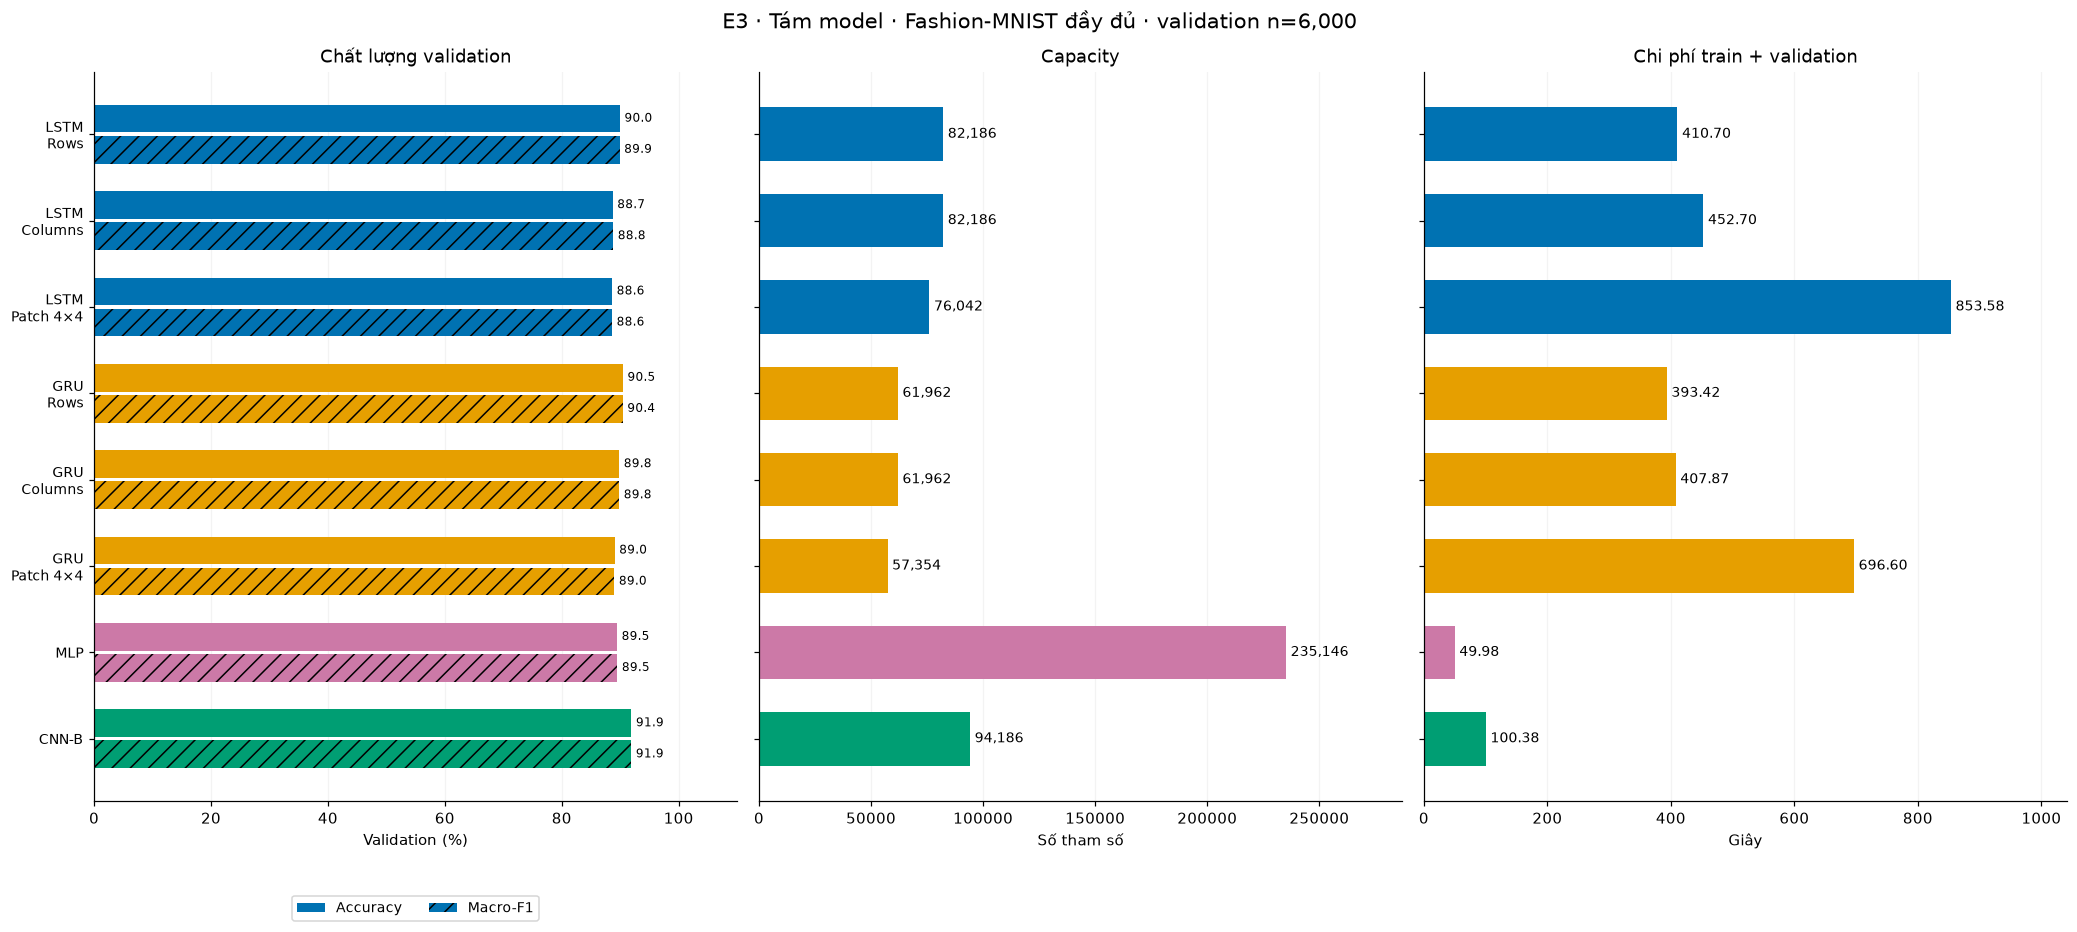

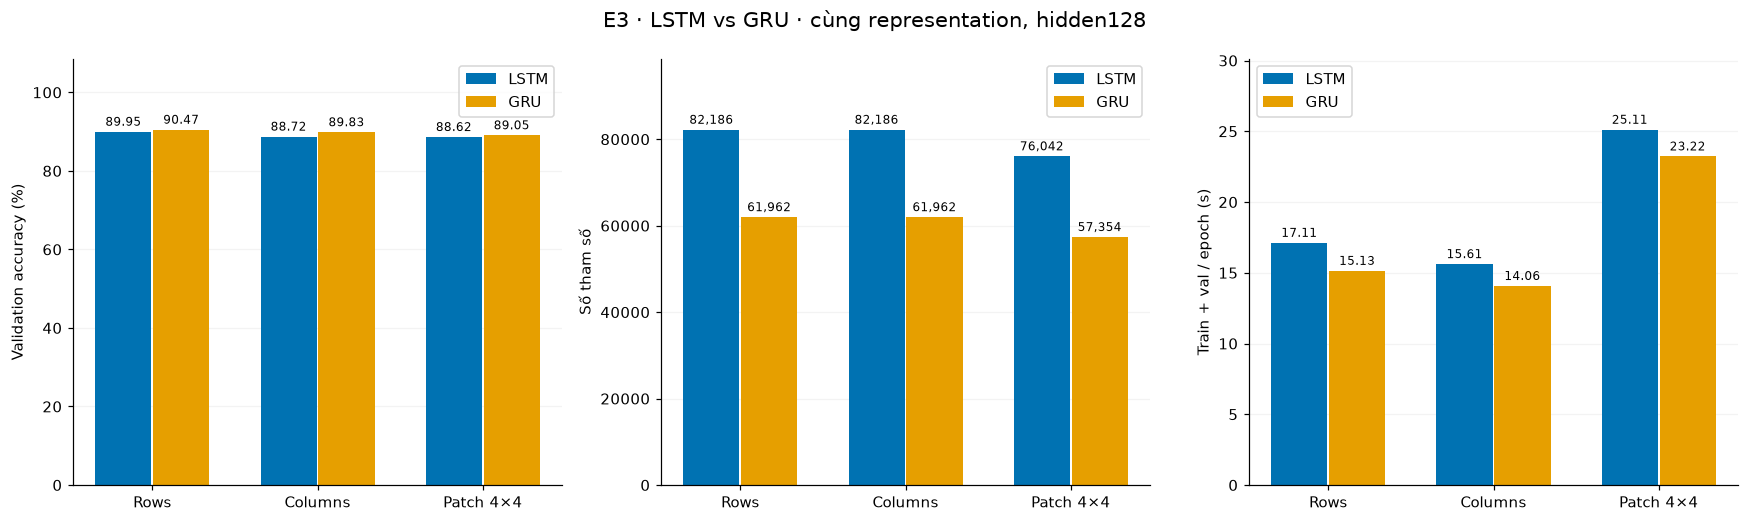

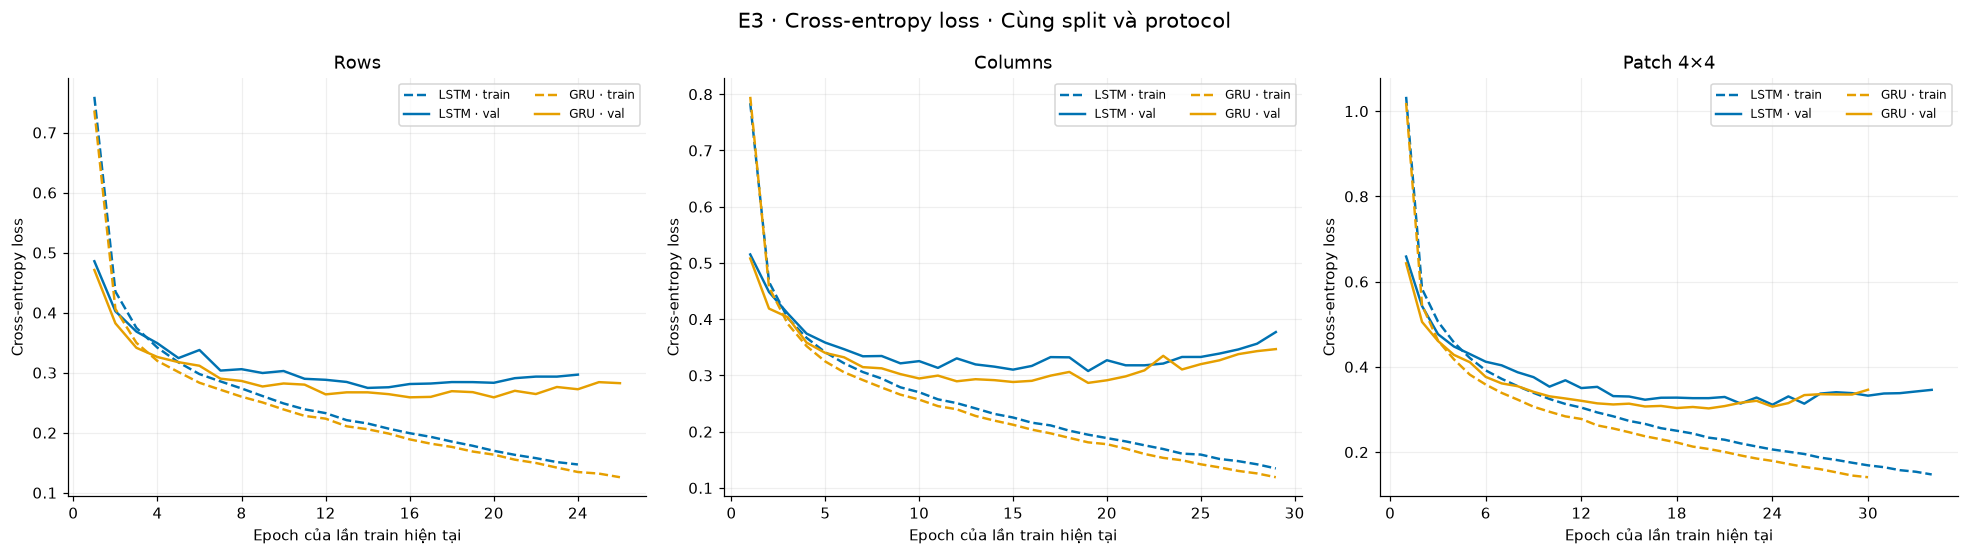

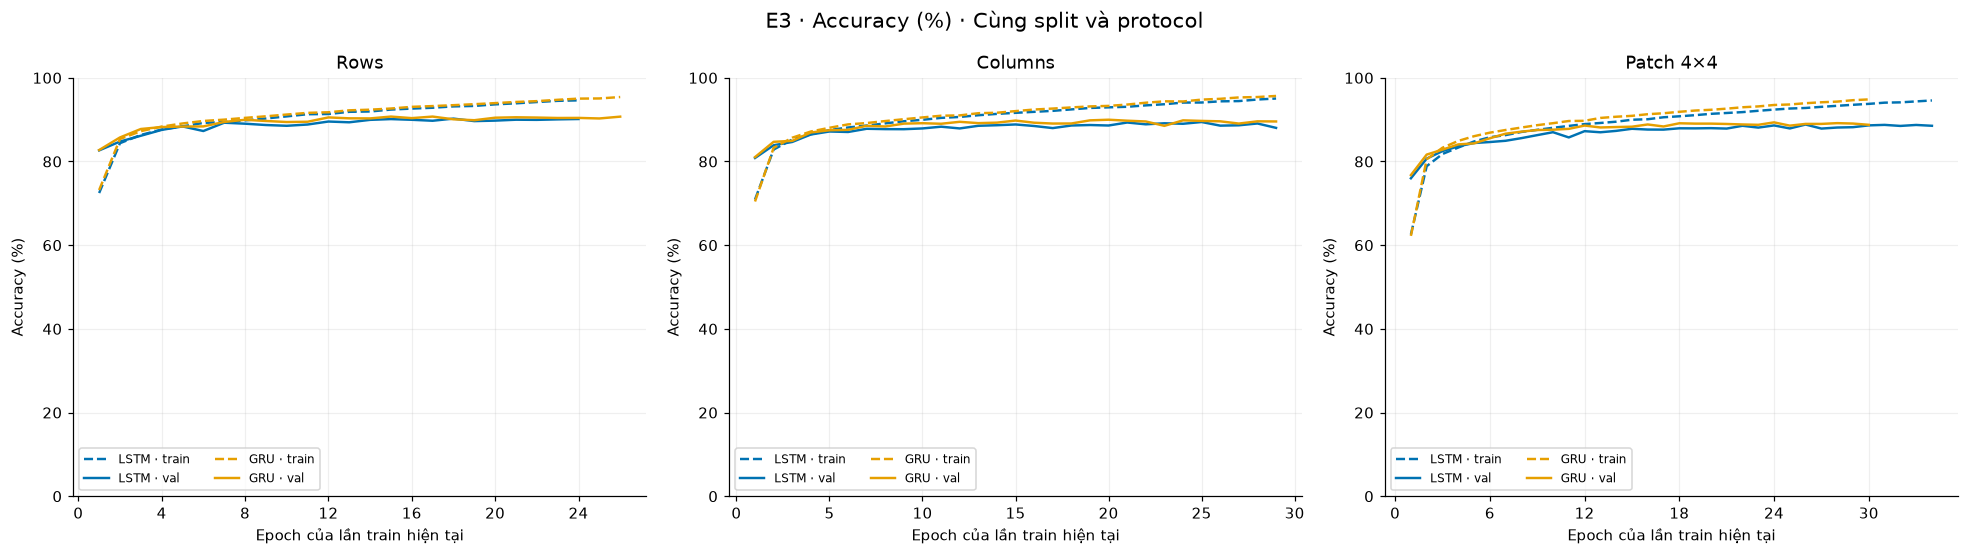

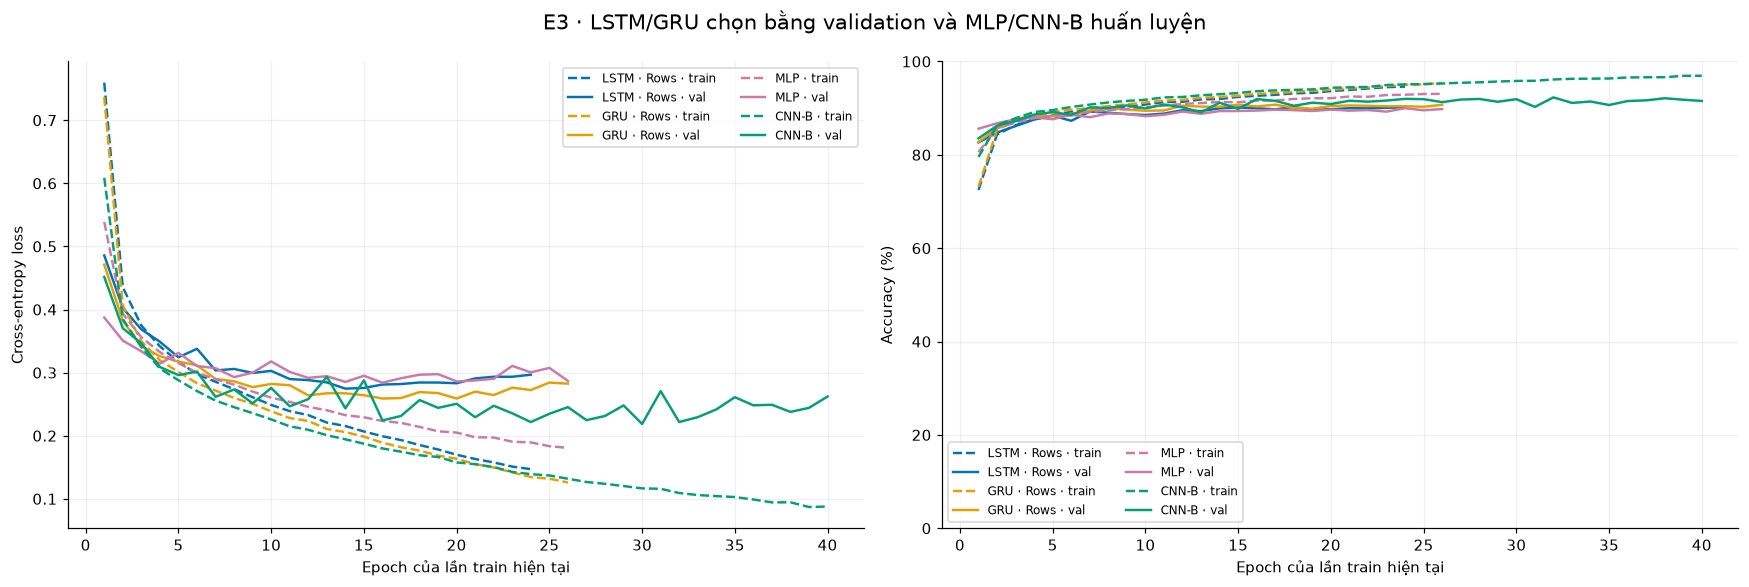

| Model | Val acc (%) | Test acc (%) | Tham số | Train + val (s/epoch) |
|---|---:|---:|---:|---:|
| LSTM · Rows | 89.95 | 89.70 | 82,186 | 17.113 |
| GRU · Rows | 90.47 | 90.06 | 61,962 | 15.132 |
| MLP | 89.47 | 89.45 | 235,146 | 1.922 |
| CNN-B | 91.92 | 91.97 | 94,186 | 2.509 |

In [12]:
log(
    "BẢNG KẾT QUẢ",
    "So sánh LSTM/GRU từng representation và baseline MLP/CNN-B train nội bộ.",
)
display_result_table(results, histories)
comparison_plot(results)
pairs = [
    (REPRESENTATION_LABELS[rep], f"lstm_{rep}", f"gru_{rep}")
    for rep in REPRESENTATION_LABELS
]
paired_comparison(
    results,
    pairs,
    ["LSTM", "GRU"],
    "recurrent_representation_comparison",
    "LSTM vs GRU · cùng representation, hidden128",
)
groups = [
    (REPRESENTATION_LABELS[rep], [f"lstm_{rep}", f"gru_{rep}"])
    for rep in REPRESENTATION_LABELS
]
plot_curve_groups(histories, groups)
by_run = {r["run"]: r for r in results}
selected_results = [by_run[run] for run in selected_runs]
plot_focus_curves(
    selected_results,
    histories,
    "baseline_curves",
    "LSTM/GRU chọn bằng validation và MLP/CNN-B huấn luyện",
)
lines = [
    "| Model | Val acc (%) | Test acc (%) | Tham số | Train + val (s/epoch) |",
    "|---|---:|---:|---:|---:|",
]
for result in selected_results:
    lines.append(
        f"| {result['model']} | {100 * result['val_accuracy']:.2f} | {100 * result['test_accuracy']:.2f} | {result['parameters']:,} | {result['seconds_per_epoch']:.3f} |"
    )
display(Markdown("\n".join(lines)))

## 10. Confusion matrix và ảnh lỗi
Đủ 8 matrix test; cặp LSTM/GRU cùng representation, rồi cặp MLP/CNN-B. Mỗi ô số ảnh và % hàng, cùng thang màu. Ảnh lỗi gộp LSTM/GRU chọn bằng validation với hai baseline; ma trận số lưu đủ 8 model.

[03:54:47] [BÁO CÁO LỖI] Đủ 8 confusion matrix test: LSTM/GRU cùng representation, rồi MLP/CNN-B.
[03:54:47] [CONFUSION MATRIX] Test: bốn cặp đặt ngang; mỗi ô = số ảnh và % theo hàng.
[HÌNH] confusion_test_pair_1 · hiển thị trong output cell
[HÌNH] confusion_test_pair_2 · hiển thị trong output cell
[HÌNH] confusion_test_pair_3 · hiển thị trong output cell
[HÌNH] confusion_test_pair_4 · hiển thị trong output cell
[03:54:49] [PHÂN TÍCH LỖI] Gộp 4 lớp có recall trung bình thấp nhất; mỗi hàng một model, mỗi cột cùng lớp thật.
[HÌNH] failure_examples_test · hiển thị trong output cell


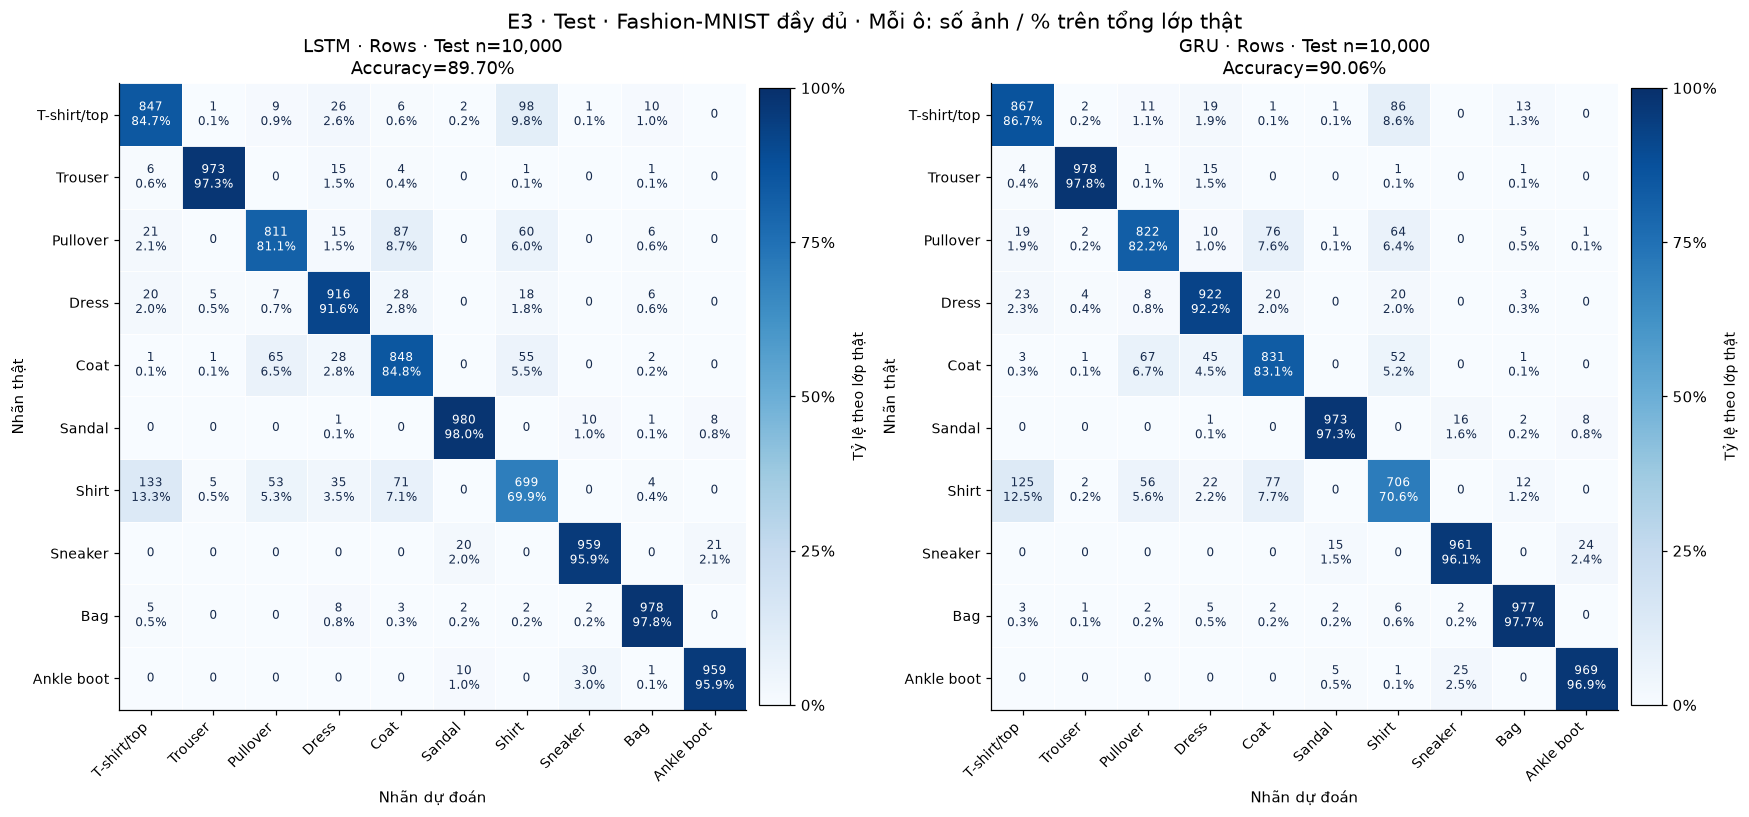

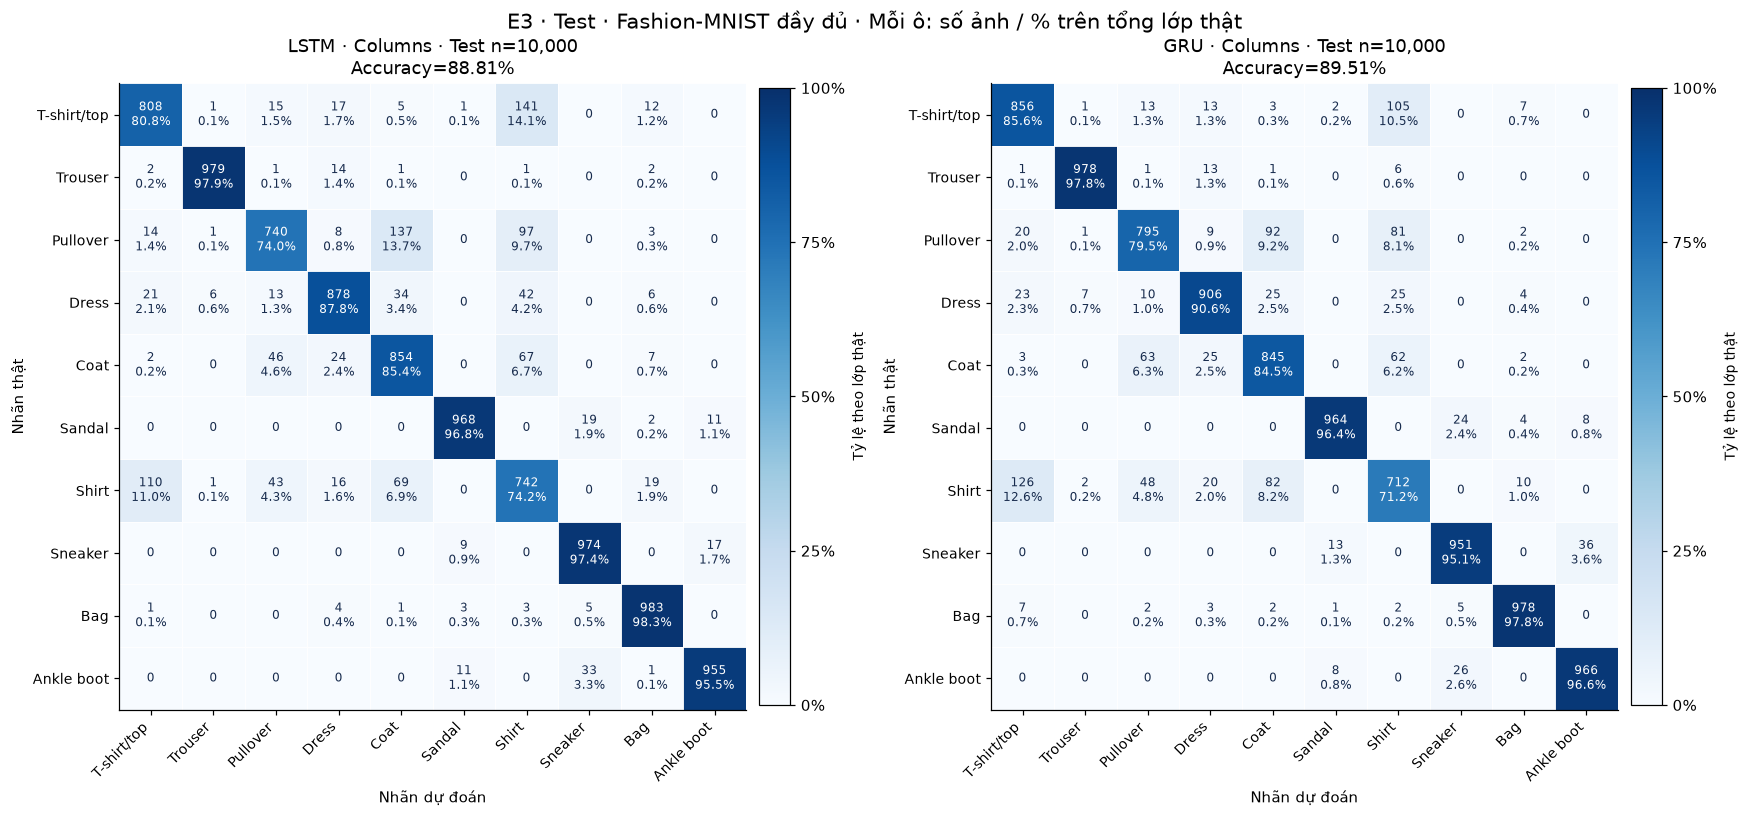

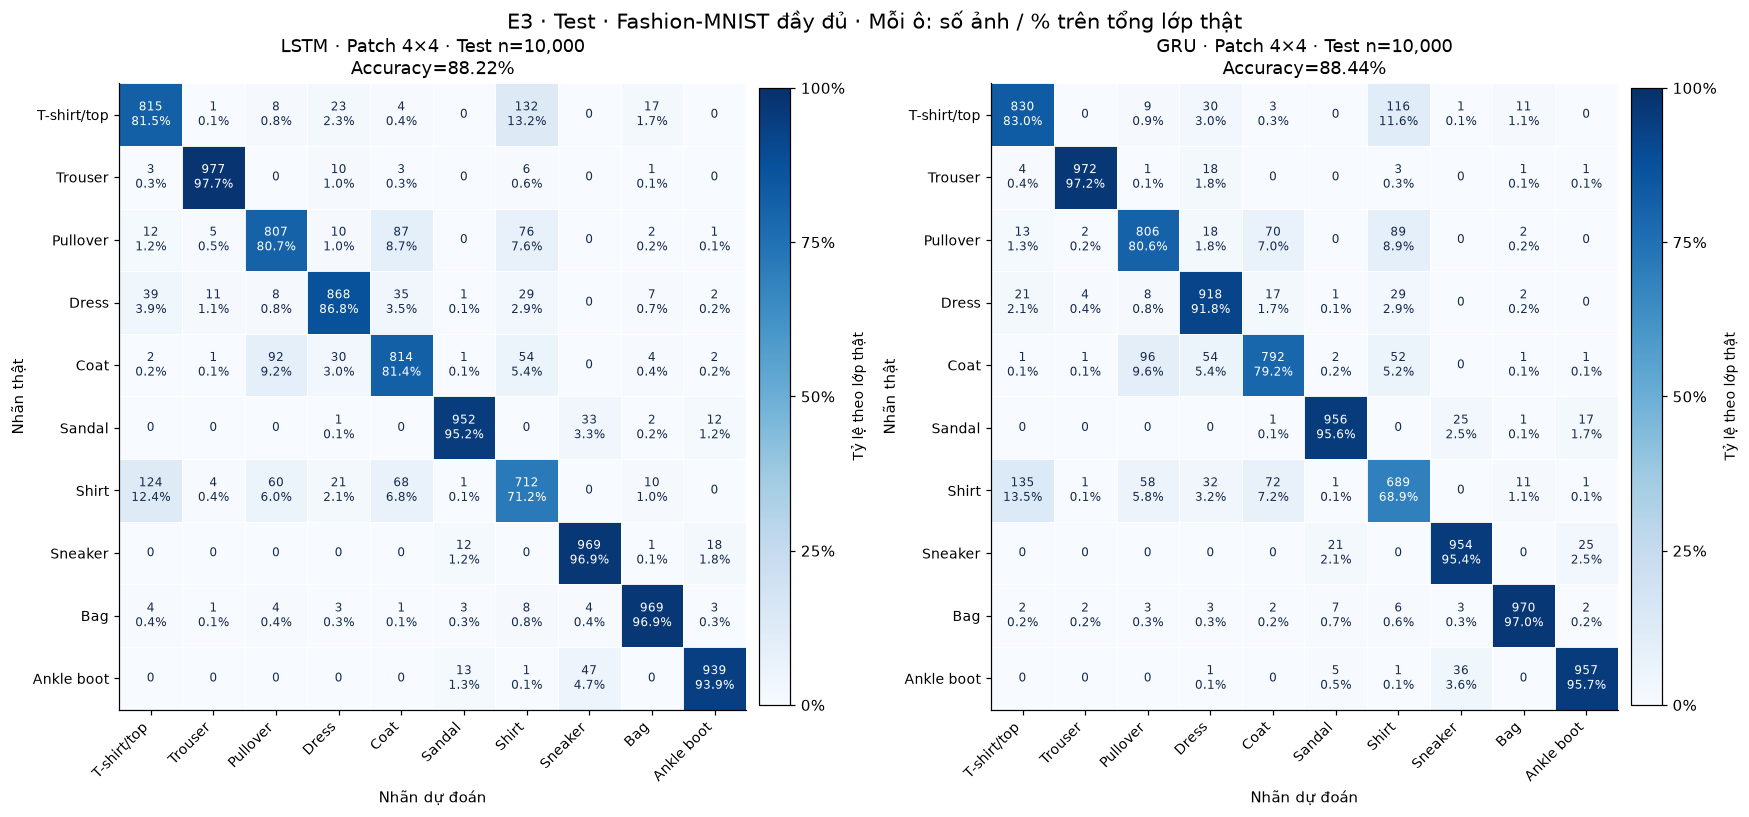

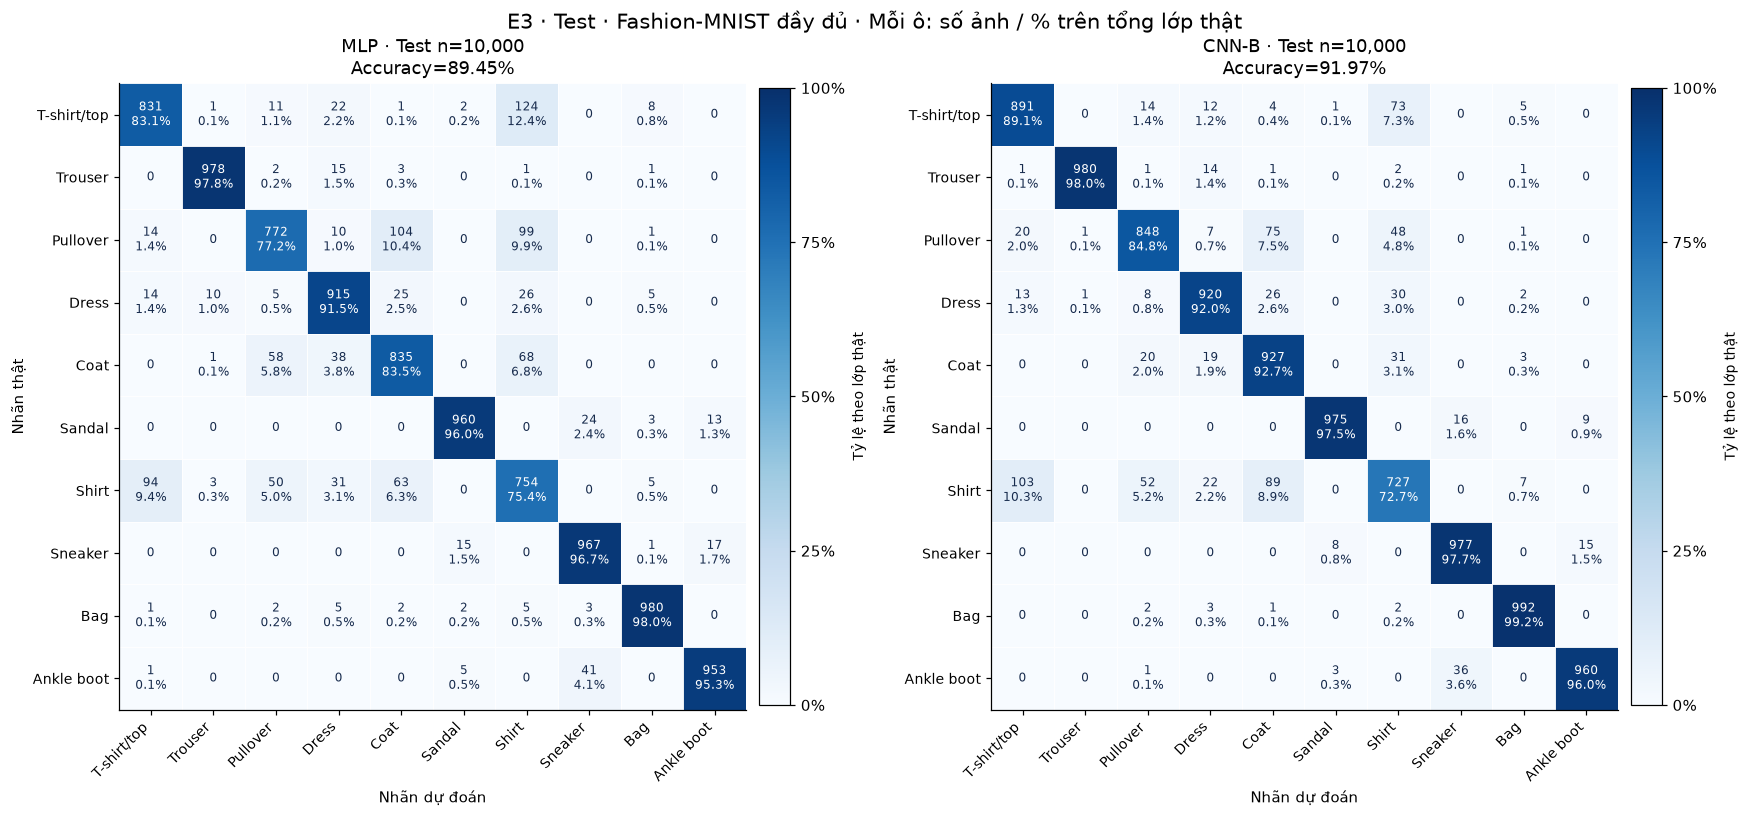

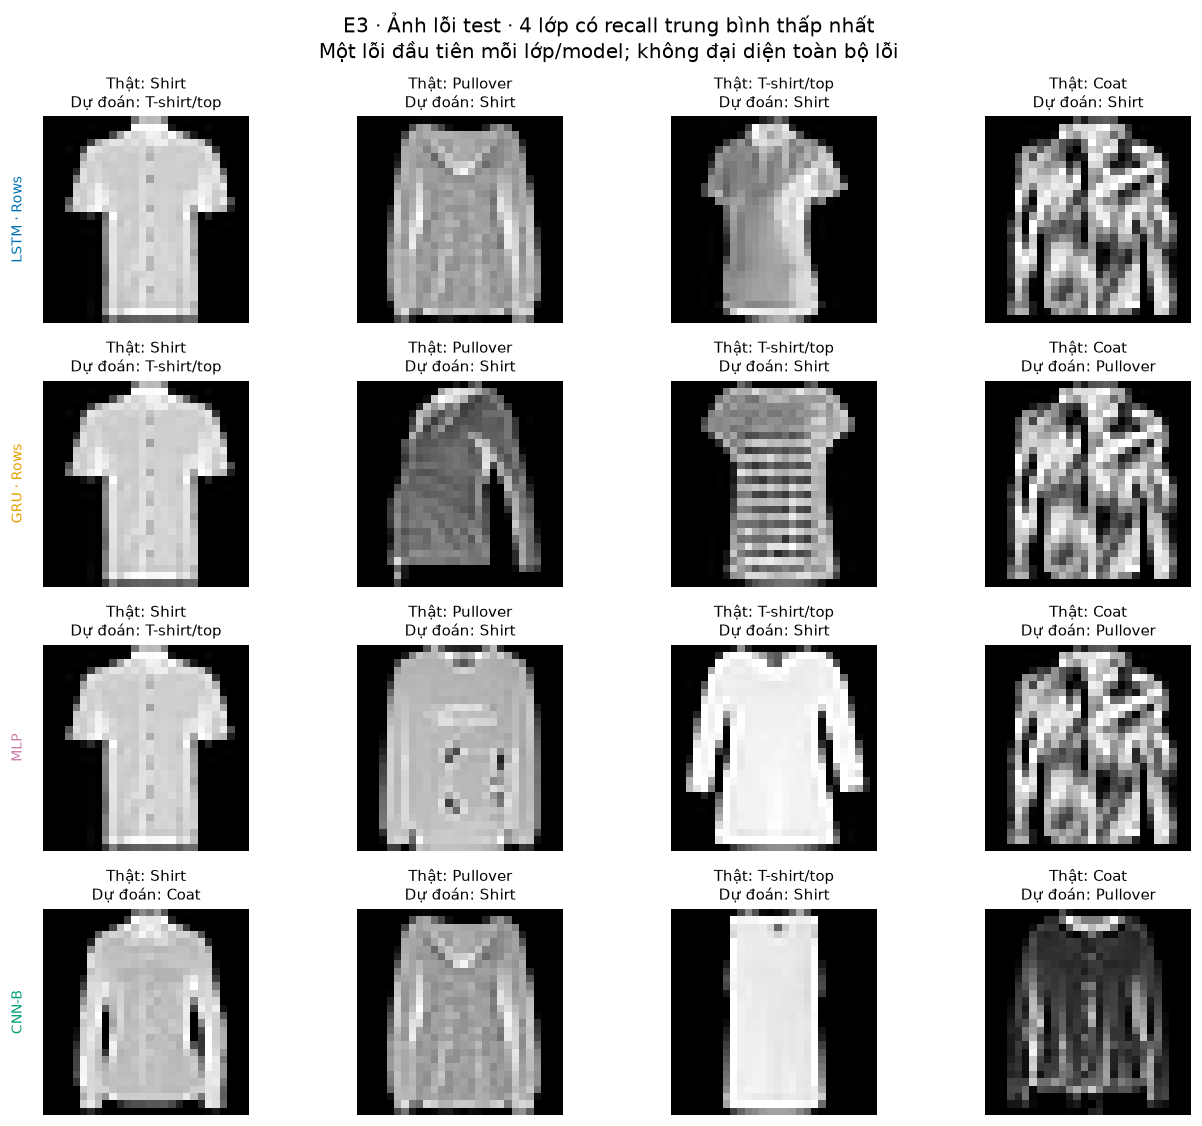

| Model | Nhầm nhiều nhất: thật → dự đoán | Số ảnh | % lớp thật |
|---|---|---:|---:|
| LSTM · Rows | Shirt → T-shirt/top | 133 | 13.3% |
| LSTM · Columns | T-shirt/top → Shirt | 141 | 14.1% |
| LSTM · Patch 4×4 | T-shirt/top → Shirt | 132 | 13.2% |
| GRU · Rows | Shirt → T-shirt/top | 125 | 12.5% |
| GRU · Columns | Shirt → T-shirt/top | 126 | 12.6% |
| GRU · Patch 4×4 | Shirt → T-shirt/top | 135 | 13.5% |
| MLP | T-shirt/top → Shirt | 124 | 12.4% |
| CNN-B | Shirt → T-shirt/top | 103 | 10.3% |

In [13]:
log(
    "BÁO CÁO LỖI",
    "Đủ 8 confusion matrix test: LSTM/GRU cùng representation, rồi MLP/CNN-B.",
)
by_run = {r["run"]: r for r in results}
ordered_runs = [
    run for rep in REPRESENTATION_LABELS for run in [f"lstm_{rep}", f"gru_{rep}"]
] + ["mlp", "cnn_b"]
confusion_plots([by_run[run] for run in ordered_runs], evaluations, "test")
failure_examples_plot([by_run[run] for run in selected_runs], evaluations, "test")

report_error_pairs(results)

## 11. Minh họa đưa ảnh thành chuỗi
Cùng một ảnh Shirt: hàng/cột là timestep, patch được đánh số 0–48 theo raster. Hình dưới biểu diễn các giá trị pixel thành timestep × feature, dùng chung thang cường độ [0,1].

[03:54:50] [BIỂU DIỄN CHUỖI] Một ảnh validation dùng chung: hình gốc/thứ tự quét và ma trận pixel theo timestep đặt thành 3 cột.
[HÌNH] sequence_representations · hiển thị trong output cell


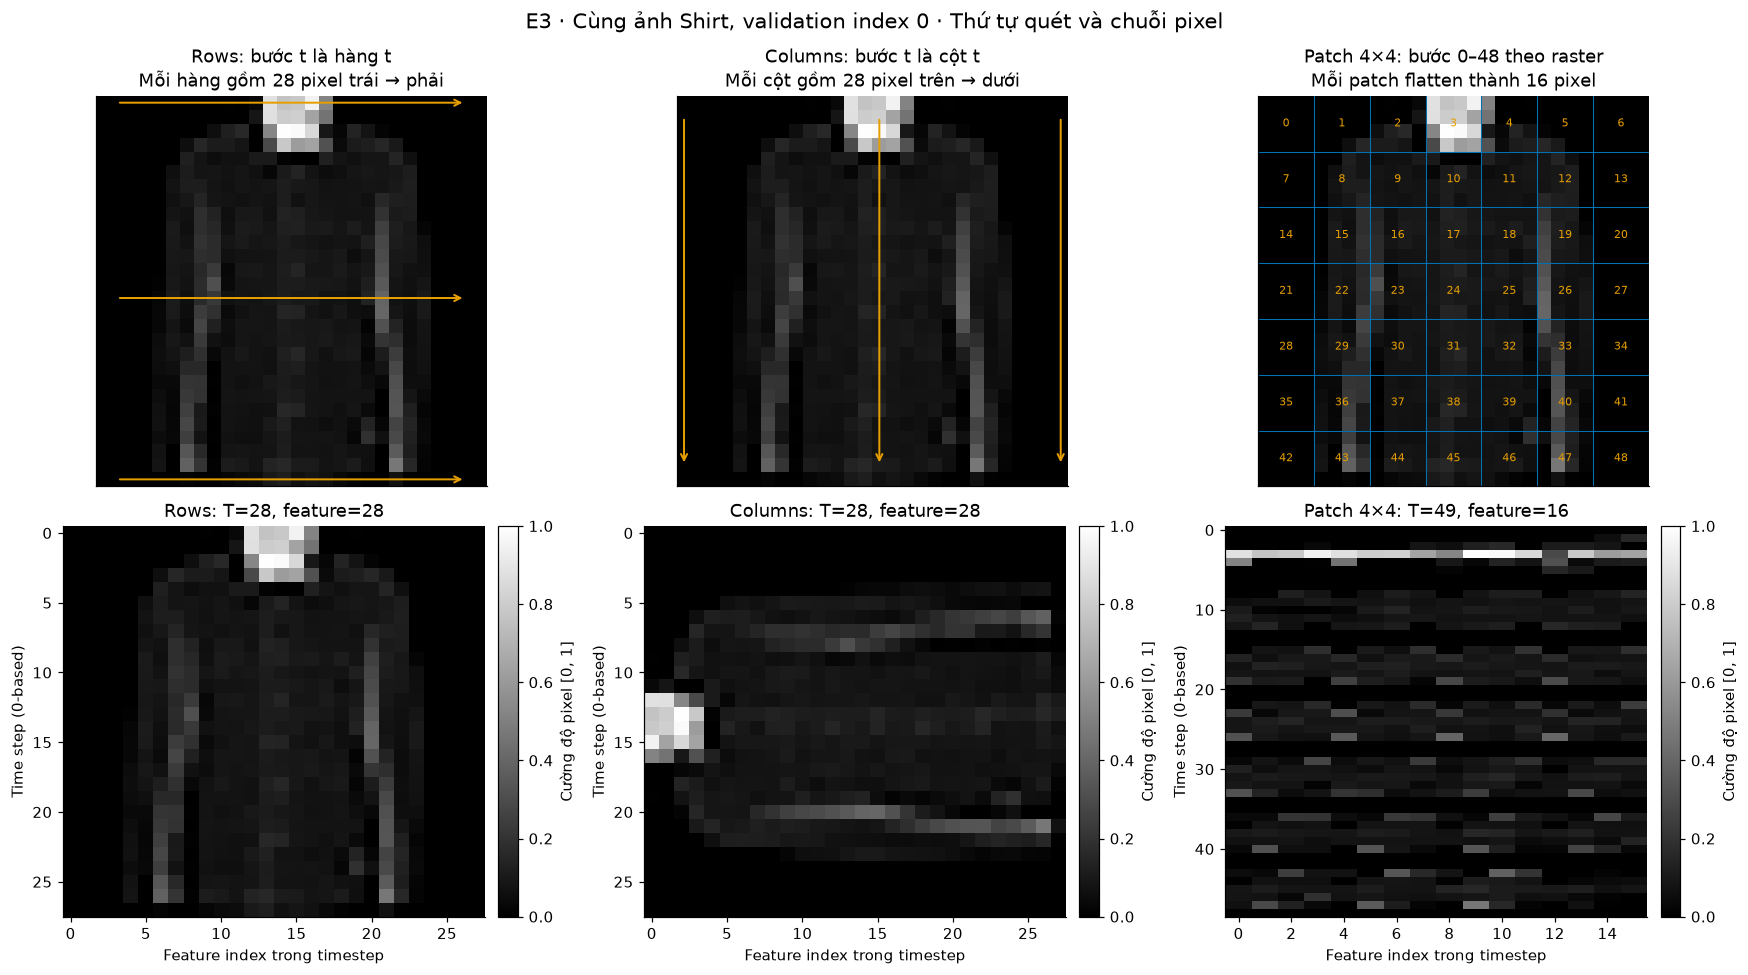

In [14]:
log(
    "BIỂU DIỄN CHUỖI",
    "Một ảnh validation dùng chung: hình gốc/thứ tự quét và ma trận pixel theo timestep đặt thành 3 cột.",
)
sample_index = int(np.flatnonzero(dataset_labels(val_set) == 6)[0])
sample = val_set[sample_index][0].unsqueeze(0) * std + mean
pixels = sample[0, 0].numpy()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for column, representation in enumerate(REPRESENTATION_LABELS):
    top, bottom = axes[:, column]
    top.imshow(pixels, cmap="gray", vmin=0, vmax=1)
    if representation == "rows":
        for row in [0, 14, 27]:
            top.annotate(
                "",
                xy=(26, row),
                xytext=(1, row),
                arrowprops={"arrowstyle": "->", "color": "#E69F00", "lw": 1.3},
            )
        top.set_title("Rows: bước t là hàng t\nMỗi hàng gồm 28 pixel trái → phải")
    elif representation == "columns":
        for col in [0, 14, 27]:
            top.annotate(
                "",
                xy=(col, 26),
                xytext=(col, 1),
                arrowprops={"arrowstyle": "->", "color": "#E69F00", "lw": 1.3},
            )
        top.set_title("Columns: bước t là cột t\nMỗi cột gồm 28 pixel trên → dưới")
    else:
        for boundary in np.arange(3.5, 28, 4):
            top.axhline(boundary, color="#0072B2", lw=0.7)
            top.axvline(boundary, color="#0072B2", lw=0.7)
        for row in range(7):
            for col in range(7):
                top.text(
                    col * 4 + 1.5,
                    row * 4 + 1.5,
                    str(row * 7 + col),
                    color="#E69F00",
                    ha="center",
                    va="center",
                    fontsize=7,
                )
        top.set_title(
            "Patch 4×4: bước 0–48 theo raster\nMỗi patch flatten thành 16 pixel"
        )
    top.set_xticks([])
    top.set_yticks([])
    sequence = image_to_sequence(sample, representation)[0].numpy()
    image = bottom.imshow(sequence, aspect="auto", cmap="gray", vmin=0, vmax=1)
    bottom.set_xlabel("Feature index trong timestep")
    bottom.set_ylabel("Time step (0-based)")
    bottom.set_title(
        f"{REPRESENTATION_LABELS[representation]}: T={sequence.shape[0]}, feature={sequence.shape[1]}"
    )
    fig.colorbar(image, ax=bottom, fraction=0.046, pad=0.03).set_label(
        "Cường độ pixel [0, 1]"
    )
fig.suptitle(
    f"E3 · Cùng ảnh Shirt, validation index {sample_index} · Thứ tự quét và chuỗi pixel",
    fontsize=14,
)
show_figure(fig, "sequence_representations")

## 12. Nhận xét dựa trên số liệu thật
So LSTM/GRU từng representation, capacity/tốc độ, phụ thuộc theo thứ tự và baseline không hồi quy. Phân tích sinh từ kết quả sau Run All.

In [15]:
log("NHẬN XÉT", "Tổng hợp số liệu thật cho cell, representation, capacity và baseline.")
best_recurrent = max(
    [best_lstm, best_gru],
    key=lambda r: (r["val_accuracy"], r["val_macro_f1"], -r["val_loss"]),
)
best_baseline = max(
    [r for r in results if r["run"] in ["mlp", "cnn_b"]],
    key=lambda r: (r["val_accuracy"], r["val_macro_f1"], -r["val_loss"]),
)
display(
    Markdown(
        f"**Toàn bộ dữ liệu:** 54.000 train / 6.000 validation / 10.000 test; huấn luyện 8 model "
        f"trong {sum(r['epochs_this_session'] for r in results)} epoch / {sum(r['optimizer_updates_this_session'] for r in results)} updates trên CUDA.\n\n"
        f"**Recurrent có validation accuracy cao nhất:** {best_recurrent['model']} {100 * best_recurrent['val_accuracy']:.2f}%; "
        f"test {100 * best_recurrent['test_accuracy']:.2f}%. "
        f"**Baseline validation cao nhất:** {best_baseline['model']} {100 * best_baseline['val_accuracy']:.2f}%. "
        f"Chênh lệch recurrent − baseline: {100 * (best_recurrent['val_accuracy'] - best_baseline['val_accuracy']):+.2f} điểm %.\n\n"
        "**Diễn giải:** Rows/Columns cùng T=28 và feature28 nhưng đổi thứ tự/phụ thuộc; patch có T=49, feature16. "
        "LSTM mang cả hidden và cell state, GRU mang hidden; trong code này đều unroll theo từng token, hidden128. "
        "Số gates/tham số và chiều dài chuỗi ảnh hưởng capacity/tốc độ. "
        "MLP không dùng cấu trúc không gian trực tiếp; CNN có locality và chia sẻ trọng số. "
        "Khác biệt accuracy không tự chứng minh model đã học phụ thuộc xa; cần đối chiếu biểu diễn, "
        "learning curves và lỗi. Gradient clipping norm1 chỉ dùng recurrent; baseline giữ protocol tương ứng. "
        "Thời gian tổng bị ảnh hưởng early stopping; xem thêm giây/epoch."
    )
)
finish_notebook()
log(
    "HOÀN TẤT E3",
    f"Hoàn tất trong {time.perf_counter() - SESSION_STARTED:.2f}s; kết quả nằm trong các output cell.",
)

[03:54:50] [NHẬN XÉT] Tổng hợp số liệu thật cho cell, representation, capacity và baseline.
[03:54:50] [THÍ NGHIỆM] Hoàn tất đánh giá 8 model trên toàn bộ test.
[03:54:50] [HOÀN TẤT E3] Hoàn tất trong 3382.94s; kết quả nằm trong các output cell.


**Toàn bộ dữ liệu:** 54.000 train / 6.000 validation / 10.000 test; huấn luyện 8 model trong 238 epoch / 100434 updates trên CUDA.

**Recurrent có validation accuracy cao nhất:** GRU · Rows 90.47%; test 90.06%. **Baseline validation cao nhất:** CNN-B 91.92%. Chênh lệch recurrent − baseline: -1.45 điểm %.

**Diễn giải:** Rows/Columns cùng T=28 và feature28 nhưng đổi thứ tự/phụ thuộc; patch có T=49, feature16. LSTM mang cả hidden và cell state, GRU mang hidden; trong code này đều unroll theo từng token, hidden128. Số gates/tham số và chiều dài chuỗi ảnh hưởng capacity/tốc độ. MLP không dùng cấu trúc không gian trực tiếp; CNN có locality và chia sẻ trọng số. Khác biệt accuracy không tự chứng minh model đã học phụ thuộc xa; cần đối chiếu biểu diễn, learning curves và lỗi. Gradient clipping norm1 chỉ dùng recurrent; baseline giữ protocol tương ứng. Thời gian tổng bị ảnh hưởng early stopping; xem thêm giây/epoch.


## 13. Tái lập thí nghiệm

Chọn kernel **Python 3.14 có PyTorch CUDA**, mở notebook trong `source_code`,
rồi **Restart Kernel → Run All**. Dữ liệu: toàn bộ Fashion-MNIST đã chia thành
54.000 train / 6.000 validation / 10.000 test. Seed42, AdamW, batch128;
giới hạn100 epoch, patience4, min_delta0,0001.

Code, training loop, kiểm chứng và trình bày kết quả nằm trong notebook này.
`RUN_CONFIGS` giữ cấu hình mỗi model; `histories` giữ metric từng epoch;
`evaluations` giữ ma trận và ví dụ lỗi; `EXECUTION_LOG` giữ log chi tiết trong RAM.
Checkpoint tốt nhất giữ trong CPU RAM cho đến khi hoàn tất đánh giá.

Bảng, hình, tiến trình và nhận xét hiển thị trong output cell.
**Save notebook** để lưu toàn bộ kết quả vào file `.ipynb`.
Nguồn dữ liệu và định dạng: [datasets/README](../datasets/README.md).
Đề bài: [exercise-vne.pdf](../assignment/exercise-vne.pdf).

Người thực hiện cần kiểm chứng, giải thích code/số liệu và khai báo phần AI hỗ trợ
theo mục1.6 của đề trước khi nộp.
